In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import yaml

germinal = pd.read_csv("/home/bri/pymol/EDA/static/germinal_outputs/scores_df_extended_with_chai.csv")
mcmahon = pd.read_csv("/home/bri/pymol/EDA/static/mcmahon_outputs/scores_df_extended_with_chai.csv")
snir = pd.read_csv("/home/bri/pymol/EDA/static/snir_outputs/scores_df_extended_with_chai.csv")
YAML_PATH =  Path("/home/bri/pymol/EDA/static/metric_directions.yaml")
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/rankings")
OUTPUT_DIR.mkdir(exist_ok=True)


print(f"Germinal:\n{germinal['binder'].value_counts()}")
print(f"McMahon:\n{mcmahon['binder'].value_counts()}")
print(f"Snir:\n{snir['binder'].value_counts()}")

snir.head()

Germinal:
binder
0    456
1     24
Name: count, dtype: int64
McMahon:
binder
0    26
1    19
Name: count, dtype: int64
Snir:
binder
0    32
1     3
Name: count, dtype: int64


,source,type,sample,binder,KD[M],af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm
0,snir_ab,original,5ifj_abc_cut,1,0.000010,2.593883,95.404666,14.690,1.855,1.993750,...,0.278017,0.960036,0.937455,0.23935,0.96685,0.87115,0.178244,0.176853,0.077992,0.072123
1,snir_ab,original,5ig7_abc_cut,1,0.000100,2.572969,95.599717,8.050,1.025,2.020938,...,0.284754,0.952718,0.925141,0.23420,0.96935,0.85870,0.175888,0.175131,0.073652,0.071622
2,snir_ab,original,5ijk_acx_cut,1,0.000001,3.486349,92.439163,26.435,4.765,5.111071,...,0.283189,0.943557,0.906099,0.08775,0.92390,0.82455,0.100218,0.135256,0.019133,0.037679
3,snir_ab,alanine_scan,5ifj_abc_cut_A_D111A,0,NaN,2.815847,95.282854,13.225,1.745,2.100000,...,0.289870,0.943841,0.908519,0.21980,0.92900,0.85605,0.178802,0.175418,0.077001,0.077862
4,snir_ab,alanine_scan,5ifj_abc_cut_A_K110A,0,NaN,2.790728,94.871984,19.975,2.845,2.275417,...,0.275365,0.961354,0.939275,0.23650,0.96220,0.87810,0.168942,0.173193,0.077093,0.074850


In [2]:
import pandas as pd

# 3 specific types
types = {
    (1, "original"): 10,       # Positive
    (0, "original"): 20,       # Hard Negative
    (0, "target_shuffle"): 20  # Easy Negative
}

# other ds
other_combined = pd.concat([mcmahon, snir], axis=0)

combined_iterations = []

for i in range(6): # 10 iterations
    parts = []
    
    # Nested unpacking: (binder, type) comes from the key, n from the value
    for (binder, type), n in types.items():
        
        # Apply both filters to get the specific pool
        subset = germinal[(germinal['binder'] == binder) & 
                          (germinal['type'] == type)]
        
        # Draw n samples from this specific pool
        parts.append(subset.sample(n=n, random_state=i))
    
    # Combine the 3 parts (10+20+20 = 50 rows total per iteration)
    iteration_df = pd.concat(parts).sample(frac=1, random_state=i)
    iteration_df["iteration"] = i

    
    # Add the iteration label to snir/mcmahon
    base_with_label = other_combined.copy()
    base_with_label["iteration"] = i
    
    # combine
    combined_iteration = pd.concat([base_with_label, iteration_df], axis=0)
    
    combined_iterations.append(combined_iteration)

# single large df where each iteration (0-9) 
df = pd.concat(combined_iterations).reset_index(drop=True)
df.to_csv(OUTPUT_DIR / "scores_df_merged_final.csv", index=False)

In [3]:
print(f"Subsampled Germinal:\n{df['source'].value_counts()}")
print(f"Subsampled Germinal:\n{df['binder'].value_counts()}")
print(f"Subsampled Germinal Types:\n{df['type'].value_counts()}")
print(f"Subsampled Germinal:\n{df['iteration'].value_counts()}")

Subsampled Germinal:
source
germinal    300
mcmahon     270
snir_ab     210
Name: count, dtype: int64
Subsampled Germinal:
binder
0    588
1    192
Name: count, dtype: int64
Subsampled Germinal Types:
type
original          360
target_shuffle    228
alanine_scan      192
Name: count, dtype: int64
Subsampled Germinal:
iteration
0    130
1    130
2    130
3    130
4    130
5    130
Name: count, dtype: int64


In [4]:
cols_to_drop=(['af3_rank', 'af3_ranking_score', 'af3_rank0_masif', 'cf_rank', 'cf_rank0_masif', 'af3_pdockq', 'cf_pdockq', 'chai_unconstrained_pdockq', 'chai_constrained_pdockq', 'boltz_free_pdockq', 'boltz_template_pdockq', 'chai_constrained_interface_iptm', 'chai_unconstrained_interface_iptm'])

scores_df = df.drop(columns=cols_to_drop)

# vllt drop 'KD[M]', 'EC50[M]' too?
scores_df.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm,iteration
0,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-609,6.376025,88.098892,14.46,1.51,...,1.031273,0.931017,0.821457,0.9208,0.4745,0.886037,0.897680,0.171786,0.758631,0
1,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-601,6.893648,87.943351,19.06,1.99,...,9.585999,0.454871,0.105424,0.0374,0.0189,0.878948,0.880200,0.147295,0.598787,0
2,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_25-609,13.189712,84.282269,154.23,10.06,...,1.967852,0.928613,0.819429,0.7323,0.5462,0.877172,0.878092,0.255400,0.682429,0
3,mcmahon,original,1,2.300000e-06,NaN,Nb.AQ100_Adiponectin,12.931578,81.319338,205.51,11.33,...,4.794119,0.632155,0.268686,0.0783,0.2570,0.882637,0.875993,0.159133,0.256621,0
4,mcmahon,original,0,NaN,NaN,Nb.AQ101_Adiponectin,13.803496,80.758365,46.76,3.01,...,4.983984,0.552838,0.212057,0.0450,0.1986,0.881152,0.878127,0.171685,0.326672,0


#### Correlation Matrix

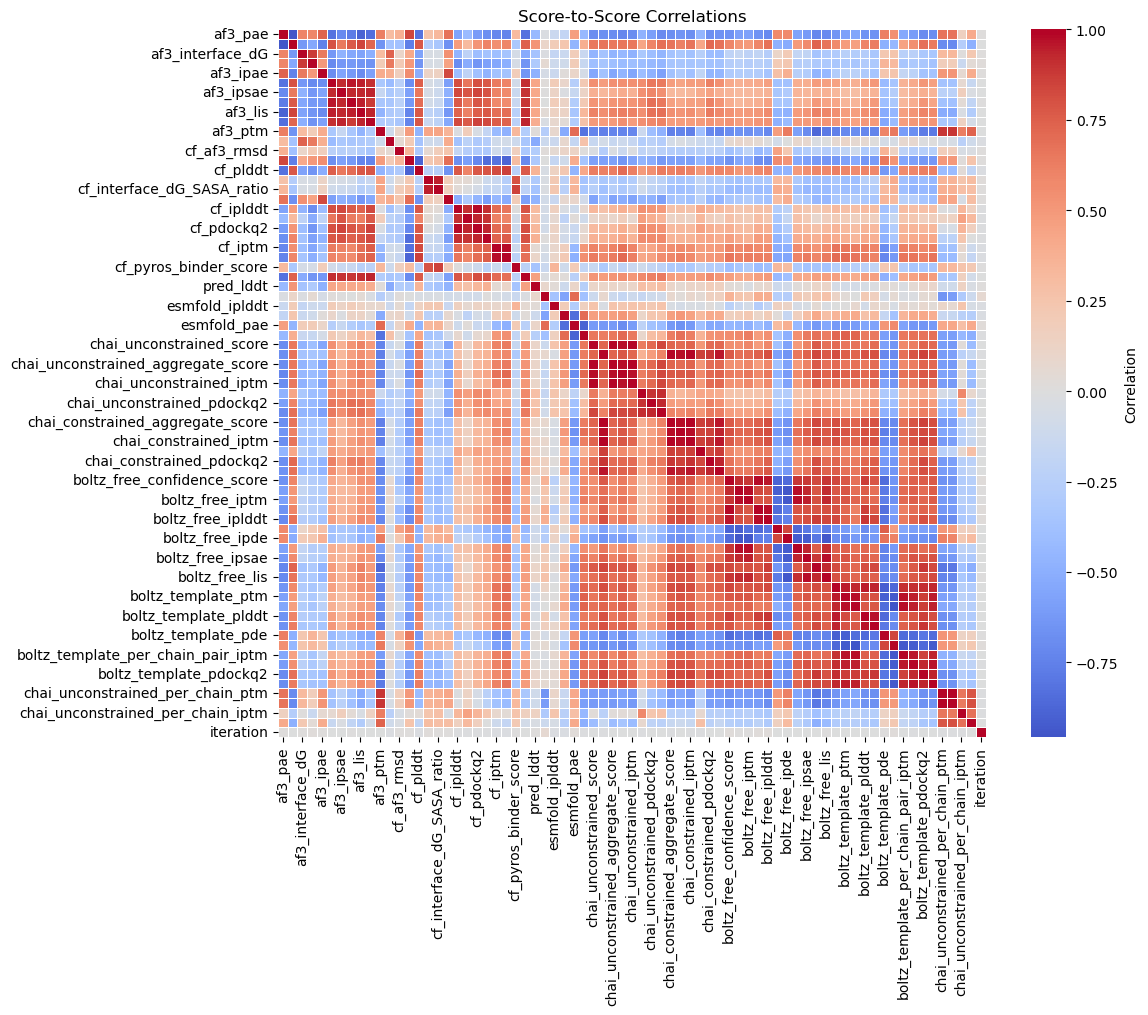

<Figure size 640x480 with 0 Axes>

In [5]:
# directions!!!!!
# Create numeric df and drop binder column
numeric_df = scores_df.select_dtypes(include=[np.number])
numeric_df = numeric_df.dropna(axis=1, how='all')
numeric_df = numeric_df.drop('binder', axis=1, errors='ignore')
numeric_df = numeric_df.drop('KD[M]', axis=1, errors='ignore')
numeric_df = numeric_df.drop('EC50[M]', axis=1, errors='ignore')


# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Score-to-Score Correlations')
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / 'score_correlation_heatmap.png', dpi=150, bbox_inches='tight')


#### Separability

In [6]:
exclude_cols = ['KD[M]', 'EC50[M]']  # columns to exclude
numeric_cols = scores_df.select_dtypes(include=['number']).columns.tolist()

# Group metrics by model (?)
models = ['af3', 'cf', 'esmfold', 'chai', 'boltz','' ]
model_groups = {model: [c for c in numeric_cols if c.startswith(model)] for model in models}

# Remove excluded columns from numeric_cols
for col in exclude_cols:
    if col in numeric_cols:
        numeric_cols.remove(col)
    

# Remove binder
if 'binder' in numeric_cols:
    numeric_cols.remove('binder')

numeric_cols
len(numeric_cols)

73

In [7]:
# Create the 3-group logic to be able to distuinguish between easy and hard negatives
def categorize_row(row):
    if row['binder'] == 1:
        return 'Binder'
    elif row['type'] == 'original': # binder = 0
        return 'Non-Binder'
    else: # binder = 0 and type = target_shuffle
        return 'Target Shuffle'

scores_df['binder_type'] = scores_df.apply(categorize_row, axis=1)

# Map the colors explicitly to the groups
colors_map = {
    'Binder': '#2ecc71',      # Green
    'Non-Binder': "#67e7dd",  # Aquamarine
    'Target Shuffle': "#273397",       # Blue
    'germinal': "#2ecc71",
    'mcmahon': "#d6a439",
    'snir_ab': "#1f3397"       
}

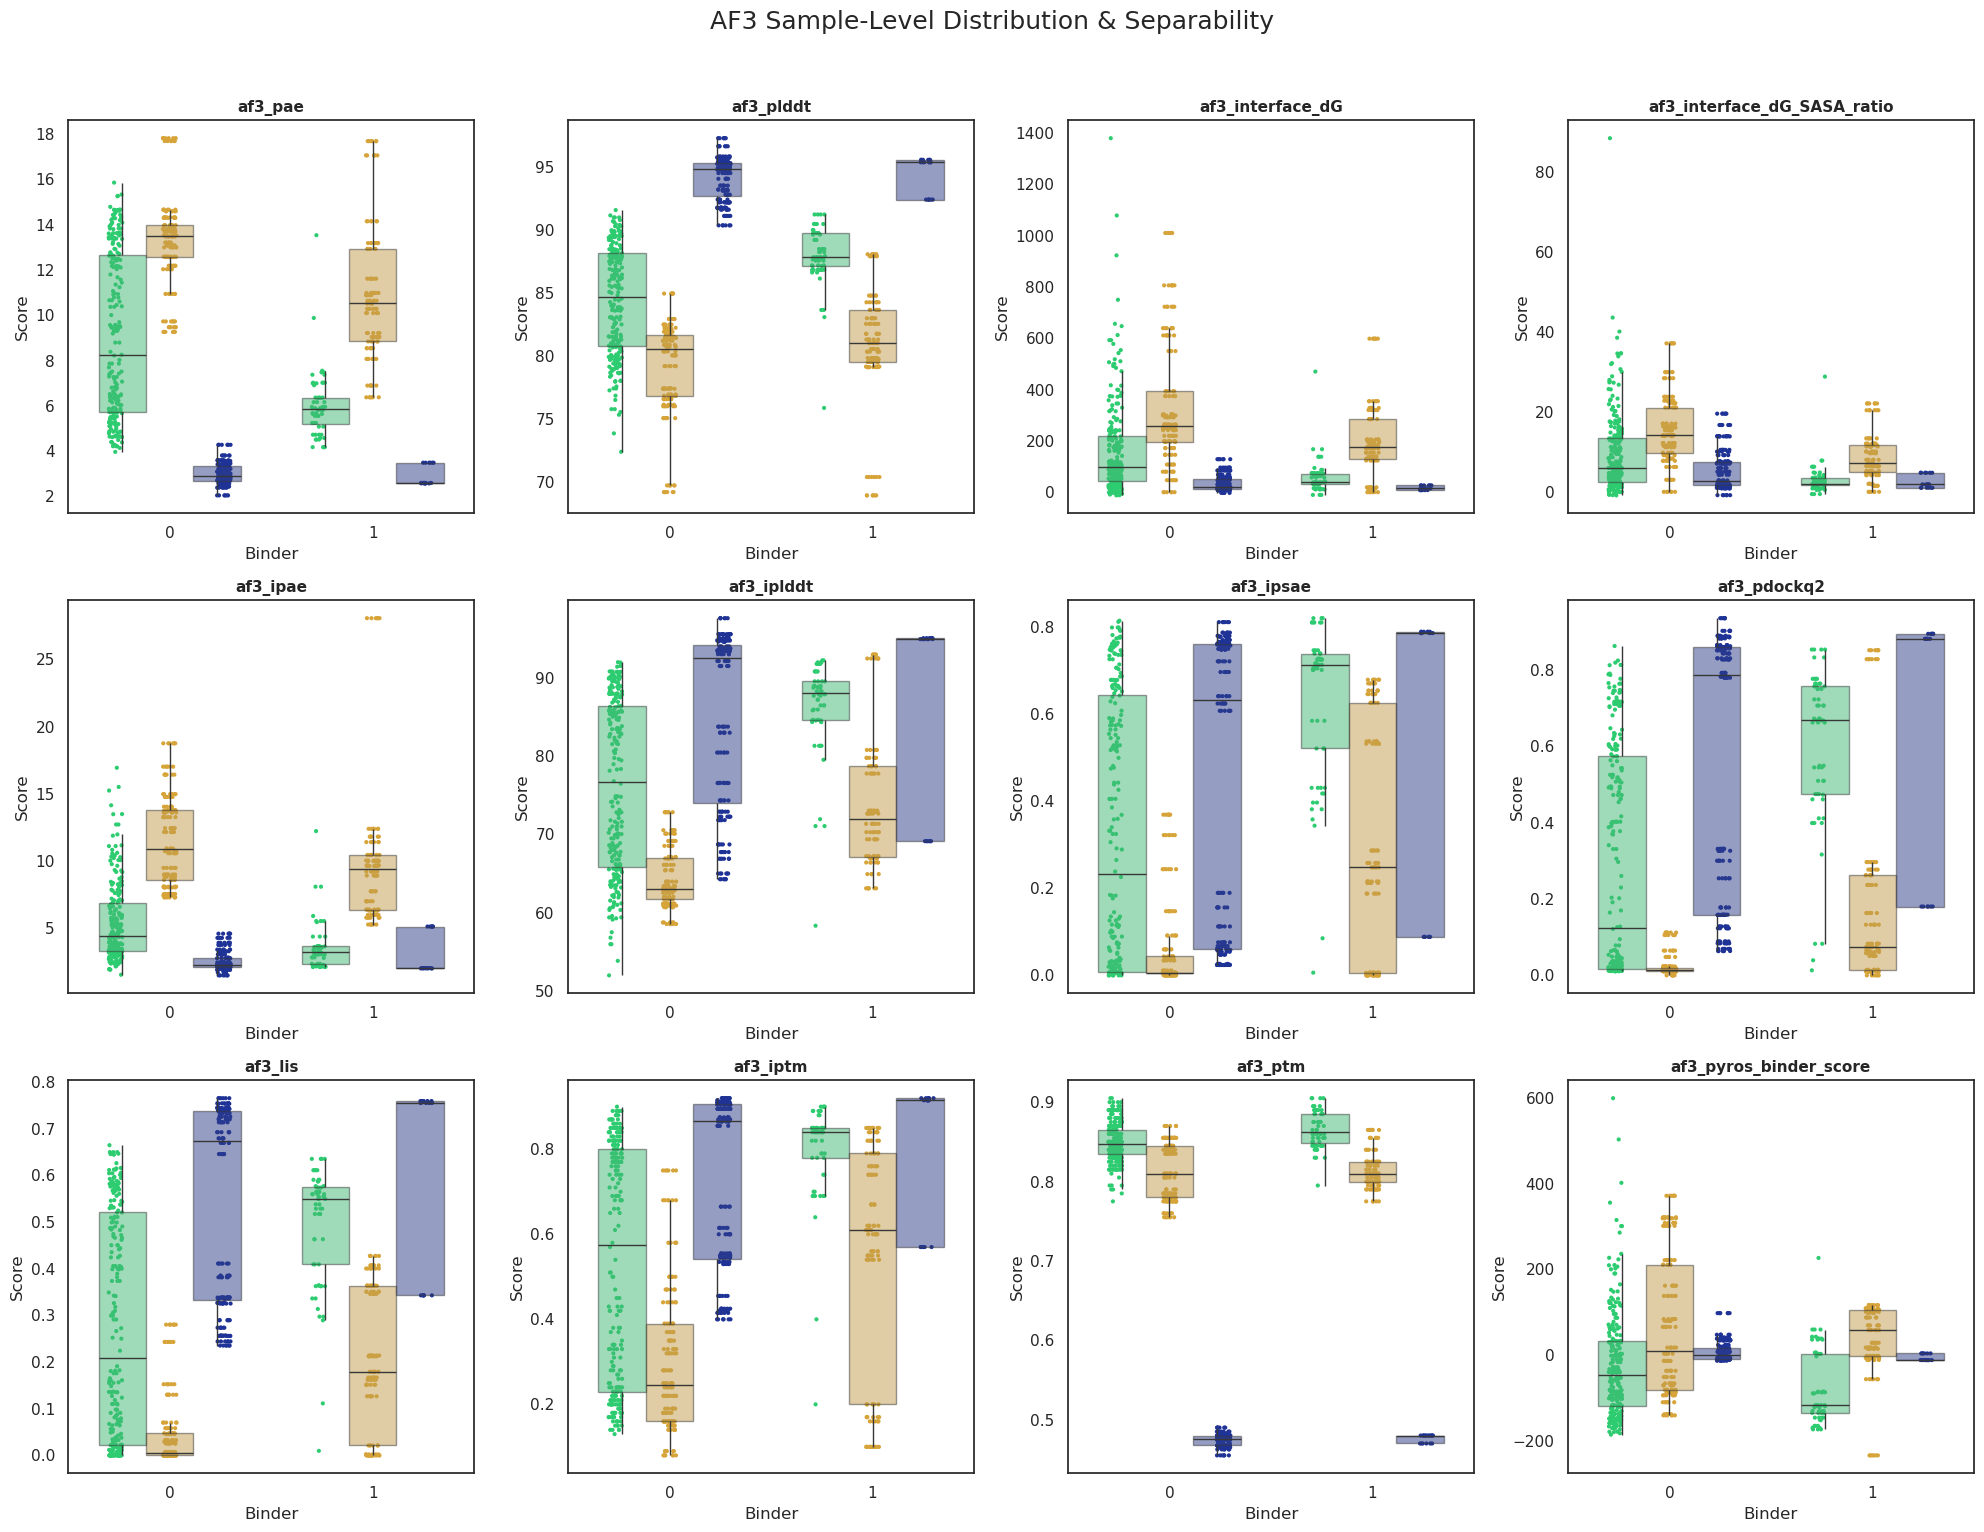

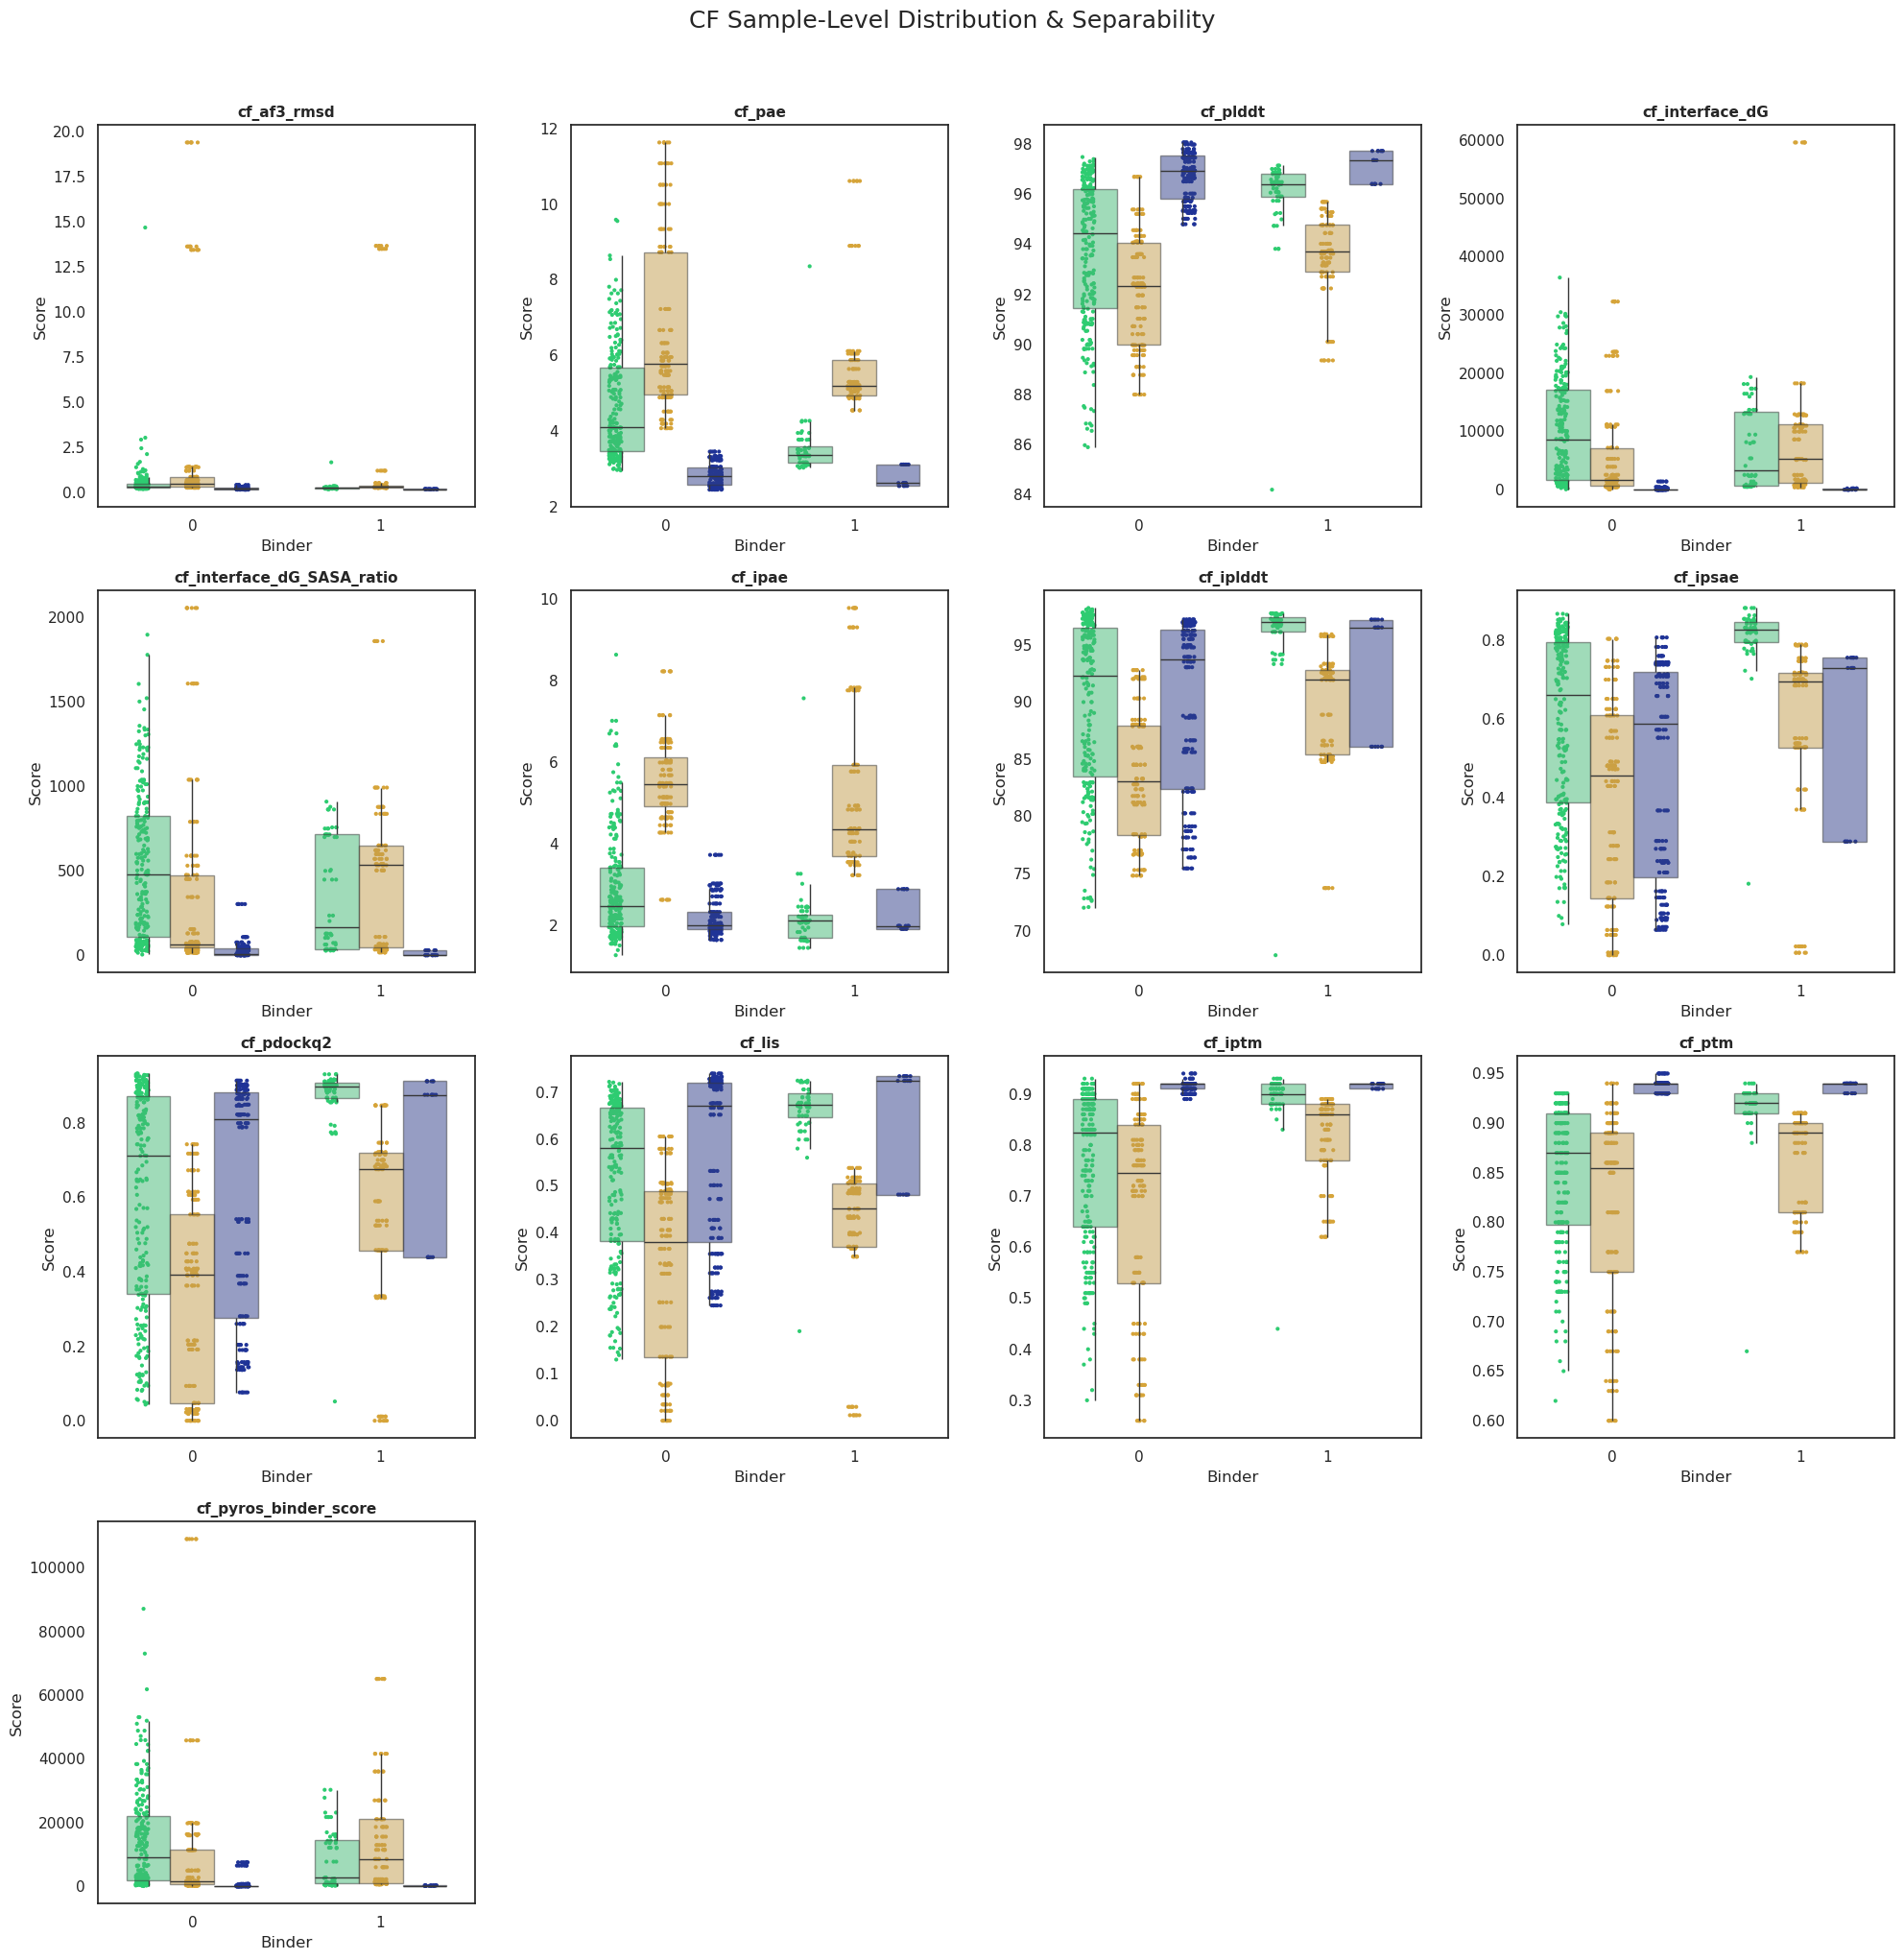

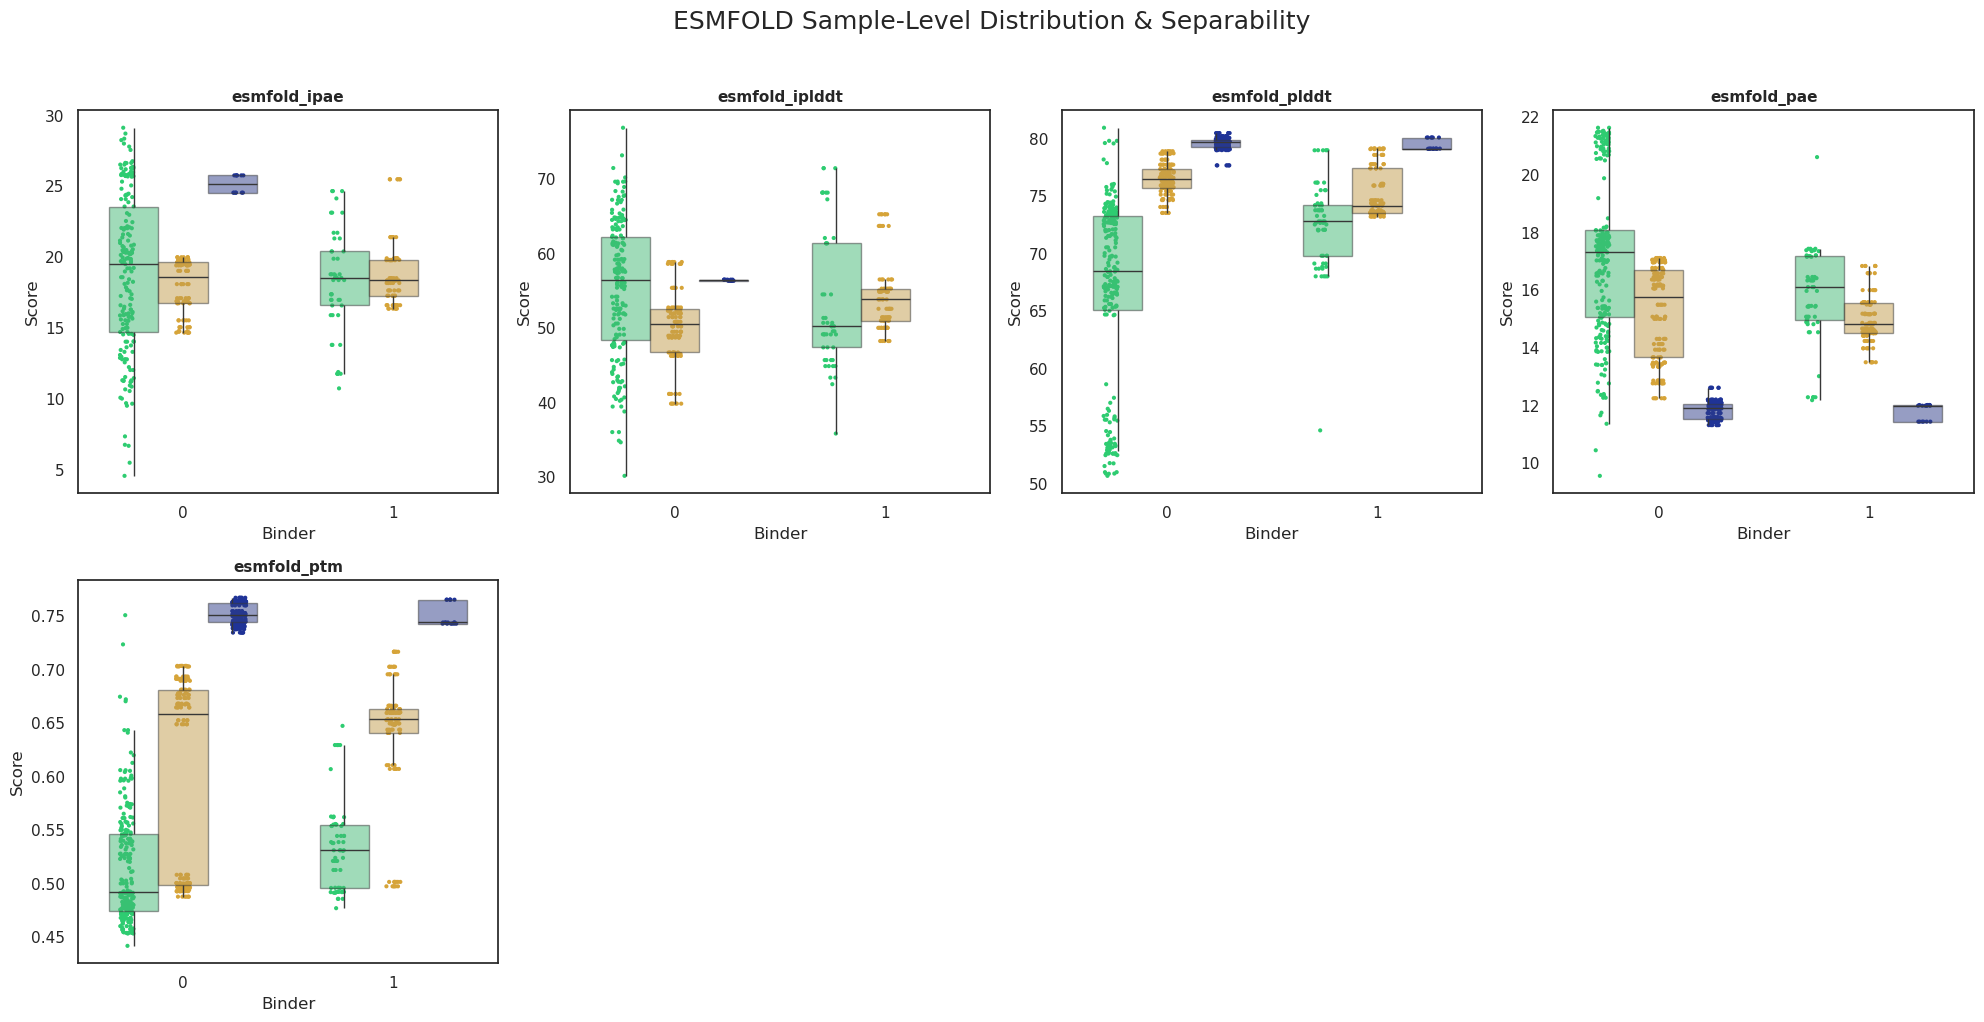

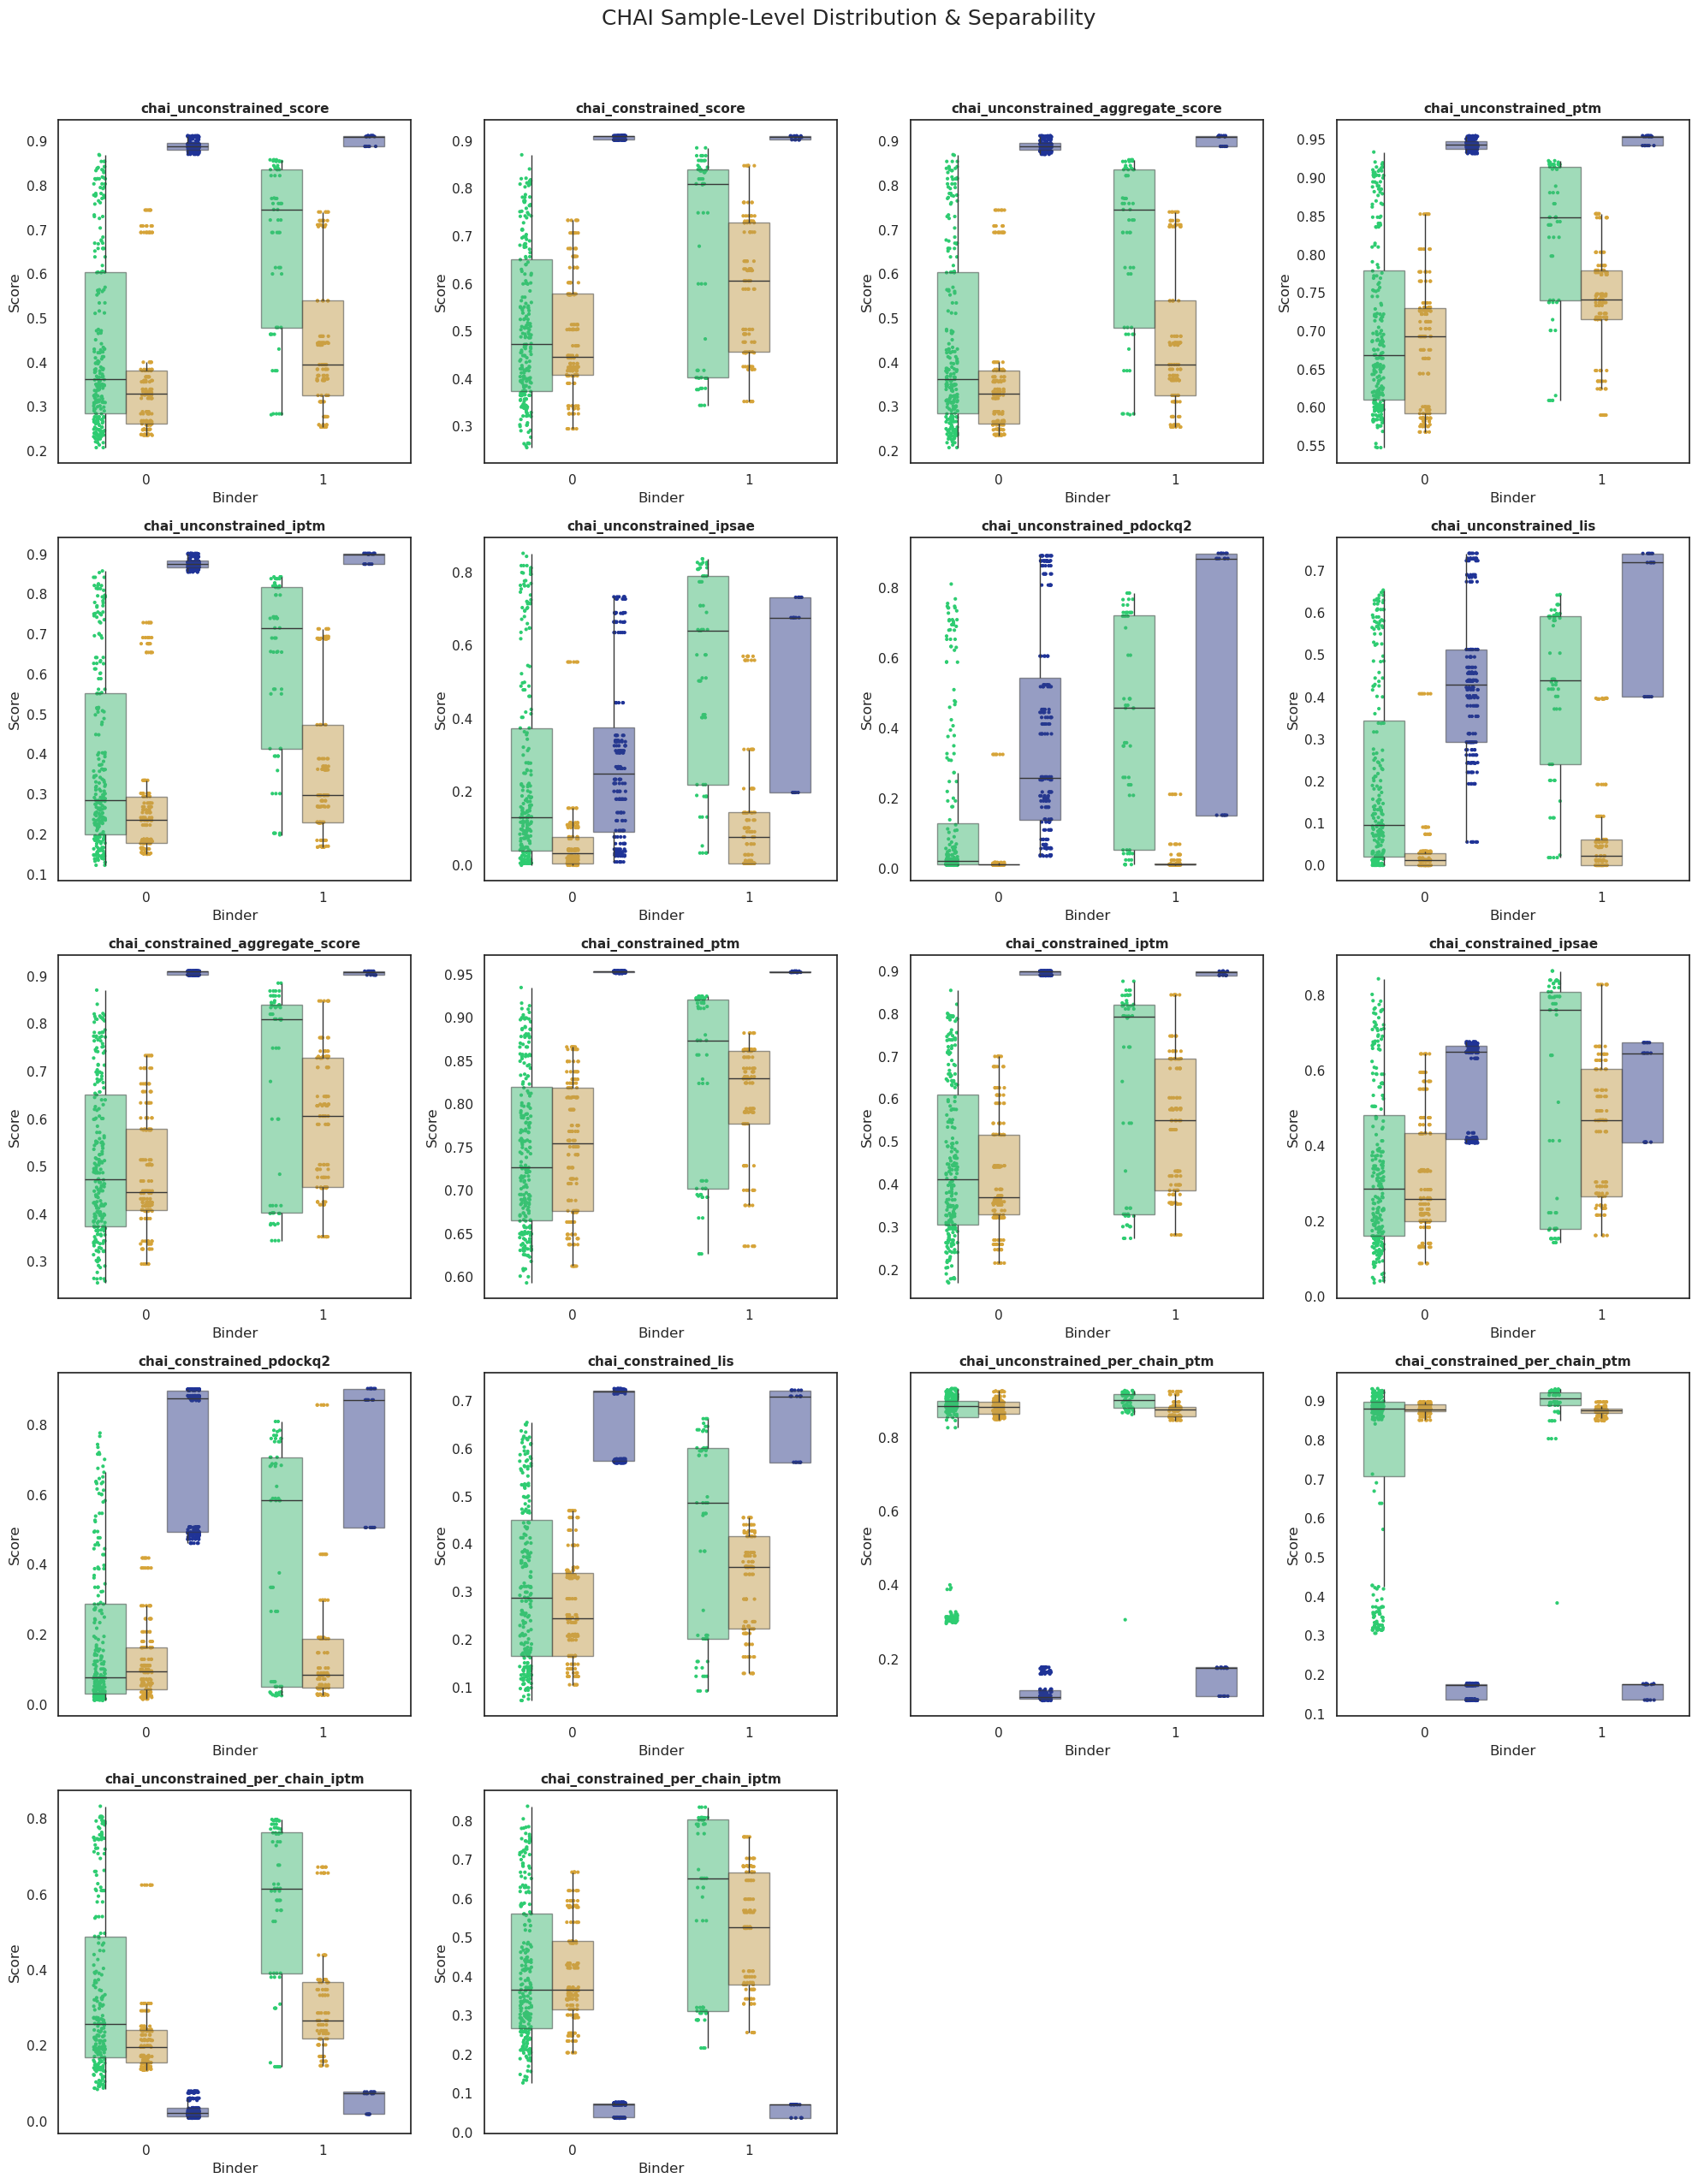

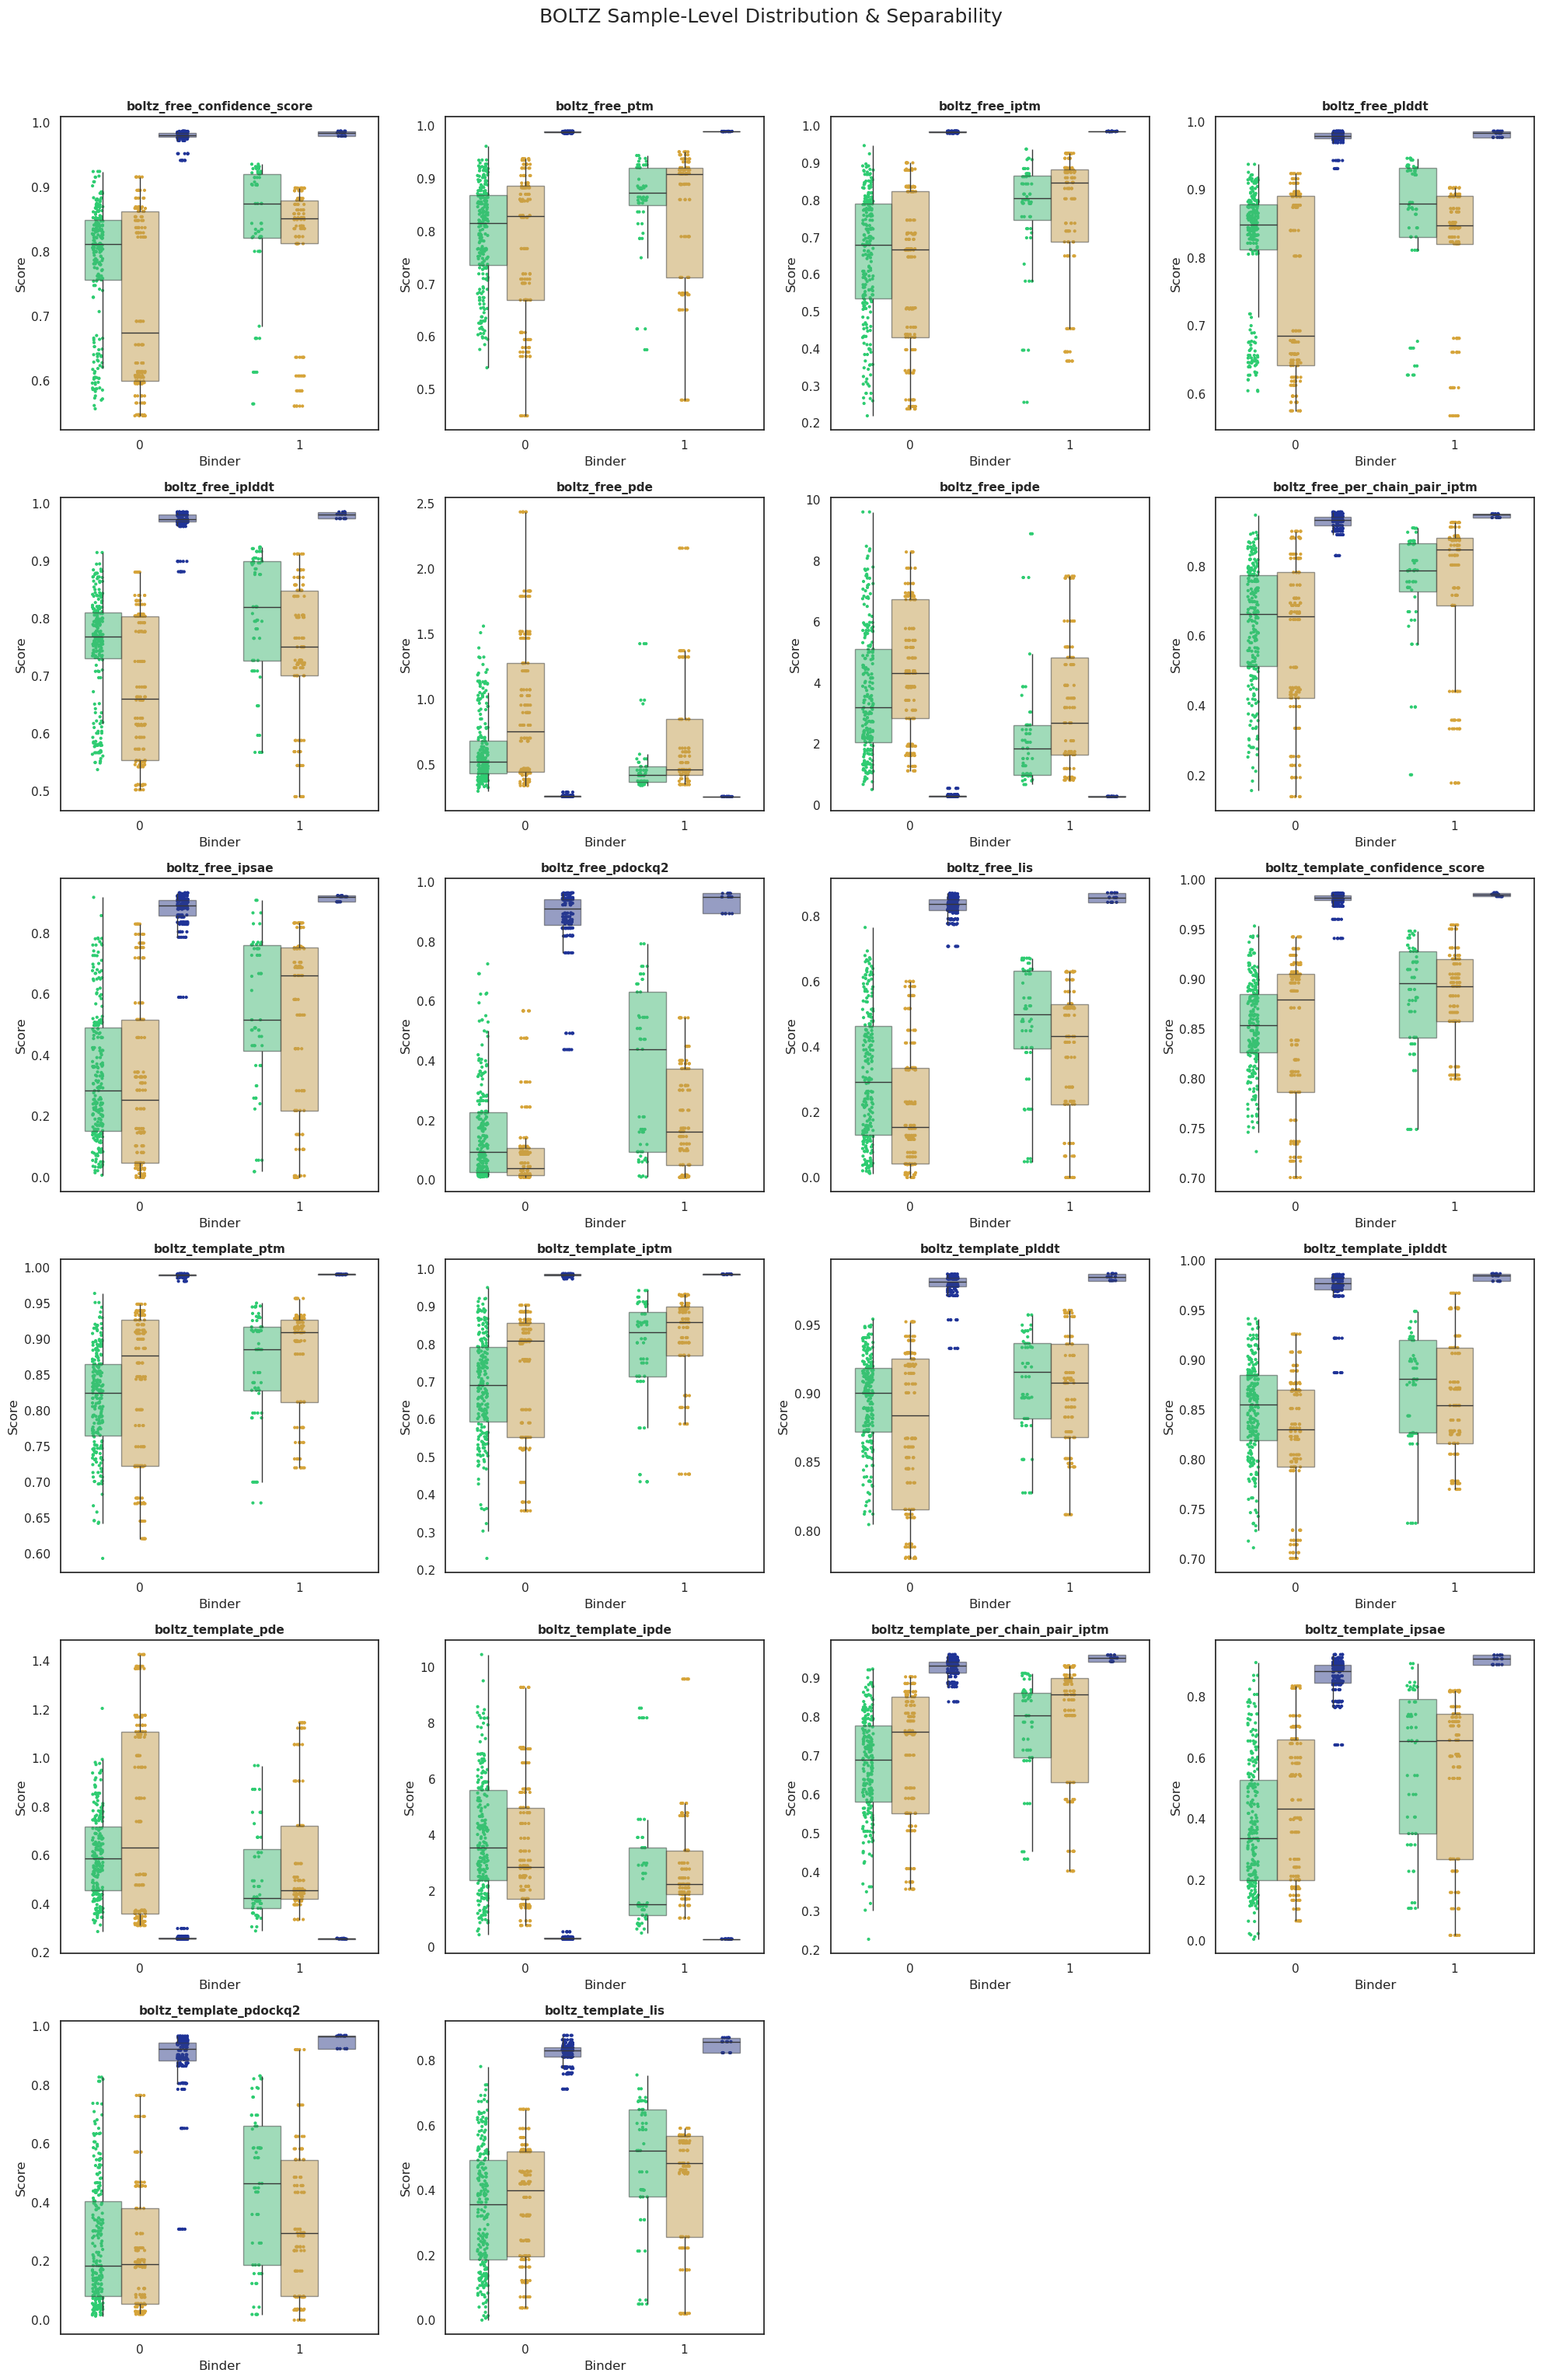

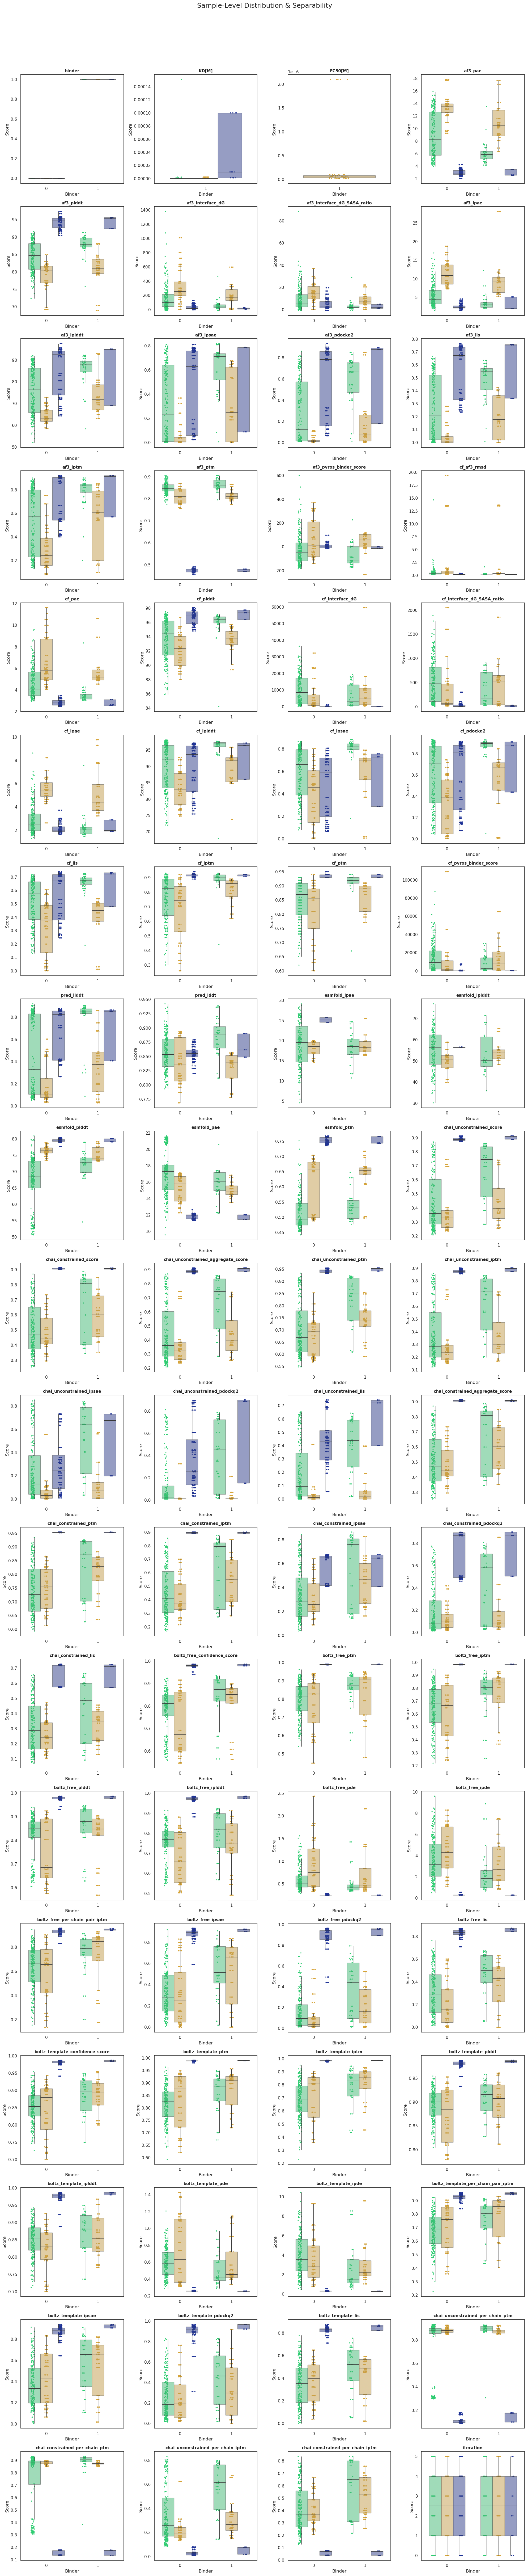

Finished generating scatterplots for  group.


In [8]:
# Detailed Separability

import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetics
sns.set_theme(style="white")

# Determine if there are multiple classes to compare
has_both_classes = scores_df['binder'].nunique() > 1

for model, cols in model_groups.items():
    if not cols: continue
    
    # Filter out columns that are entirely NaN to prevent the "bxp length" error
    valid_cols = [c for c in cols if scores_df[c].notna().any()]
    if not valid_cols:
        print(f"Skipping {model.upper()}: No valid numeric data found.")
        continue


    # Calculate grid size
    n_cols = 4
    n_rows = (len(valid_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    
    for i, col in enumerate(valid_cols):
        ax = axes[i]
        
        # df contains 'binder_type'
        plot_df = scores_df.dropna(subset=[col]).copy()

        
        if plot_df.empty:
            continue

        hue_order = sorted(plot_df['source'].unique())
        x_order = sorted(plot_df['binder'].unique())

        # Stripplot
        sns.stripplot(
            data=plot_df, 
            x='binder', 
            y=col, 
            order=x_order,
            hue='source',
            hue_order=hue_order,
            dodge=True,
            jitter=0.1, 
            palette=colors_map,
            size=3,
            ax=ax,
            legend=False 
        )
        
        # Boxplot  ???
        sns.boxplot(
            data=plot_df, 
            x='binder', 
            y=col, 
            order=x_order,
            dodge=True,
            showcaps=False, 
            fill=True, 
            hue='source',
            hue_order=hue_order,
            palette=colors_map,
            ax=ax,
            width=0.7,
            zorder=10, 
            showfliers=False,
            legend=False 
        )

        for artist in ax.patches:
            artist.set_alpha(0.5)
        
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_xlabel('Binder')
        ax.set_ylabel('Score')

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
        
    plt.suptitle(f"{model.upper()} Sample-Level Distribution & Separability", fontsize=18, y=1.02)
    plt.tight_layout()
    
    # Save output
    save_path = OUTPUT_DIR / f"{model}_separability_scatter.png"
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show() 
    
print(f"Finished generating scatterplots for {model.upper()} group.")

#### Compute metrics (ROC-AUC, PR-AUC, F1 and Precision)

In [9]:
# read metric_directions.yaml

if Path(YAML_PATH).exists():
    with open(YAML_PATH, 'r') as f:
        yaml_data = yaml.safe_load(f)
    
    # Extract directions
    raw_directions = {k: v['direction'] for k, v in yaml_data['metrics'].items()}
    metric_directions = dict(sorted(raw_directions.items(), key=lambda x: len(x[0]), reverse=True))
    print(f"Loaded {len(metric_directions)} metric directions from YAML.")
else:
    print(f"WARNING: YAML not found at {YAML_PATH}. Using default direction (+1).")
    metric_directions = {}

def get_direction(col_name):
    for base_metric, direction in metric_directions.items():
        if base_metric in col_name: 
            return direction
    return 1

Loaded 58 metric directions from YAML.


In [10]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, 
    auc as auc_pr, average_precision_score, f1_score
)

def calculate_all_metrics(df_data, numeric_cols):
    """
    Calculate comprehensive metrics for each predictor using domain knowledge from YAML.

    Uses get_direction() to determine metric direction from YAML file.
    
    Parameters:
    -----------
    df_data : DataFrame
        Data containing 'binder' column (target) and score columns
    numeric_cols : list
        List of metric column names to evaluate
    
    Returns:
    --------
    DataFrame with columns: metric, raw_roc, aligned_roc, pr_auc, f1, avg_precision, note
    """
    results = []
    
    for col in numeric_cols:
        # Skip if insufficient data
        if df_data[col].notna().sum() < 2 or df_data[col].nunique() < 2:
            continue
        
        try:
            # Clean data
            clean_data = df_data[[col, 'binder']].dropna()
            if clean_data['binder'].nunique() < 2:
                continue
            
            y_true = clean_data['binder'].astype(int)
            y_score_raw = clean_data[col].values
            

            # Step 1: Calculate Raw ROC-AUC
            raw_roc = roc_auc_score(y_true, y_score_raw)
            
            # Step 2: Get direction from YAML (domain knowledge)
            direction = get_direction(col)
            
            # Step 3: Align scores (Higher is always better)
            aligned_scores = y_score_raw * direction
            aligned_roc = max(raw_roc, 1 - raw_roc)
            
            # Step 4: Calculate PR-AUC (Average Precision)
            pr_auc = average_precision_score(y_true, aligned_scores)
            
            # Step 5: PR curve + optimal threshold from PR/F1
            precisions, recalls, thr = precision_recall_curve(y_true, aligned_scores)

            # thresholds correspond to precisions[:-1] and recalls[:-1]
            f1_scores = (
                2 * precisions[:-1] * recalls[:-1]
            ) / (
                precisions[:-1] + recalls[:-1] + 1e-8
            )

            best_idx = np.argmax(f1_scores)

            best_threshold = thr[best_idx]

            y_pred = (aligned_scores >= best_threshold).astype(int)
            max_f1 = f1_score(y_true, y_pred)

            precision = precisions[:-1][best_idx]
            recall = recalls[:-1][best_idx]
            
            
            results.append({
                'metric': col,
                'raw_roc': round(raw_roc, 4),
                'aligned_roc': round(aligned_roc, 4),
                'pr_auc': round(pr_auc, 4),
                'f1': round(max_f1, 4),
                'precision': round(precision, 4),
                'recall': round(recall, 4),
                'opt_threshold': thr[best_idx] * direction,
                'direction': direction,
            })
        except Exception as e:
            continue
    
    # Create df and sort by PR-AUC
    results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
    return results_df

In [11]:
scores_df.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_per_chain_pair_iptm,boltz_template_ipsae,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm,iteration,binder_type
0,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-609,6.376025,88.098892,14.46,1.51,...,0.931017,0.821457,0.9208,0.4745,0.886037,0.897680,0.171786,0.758631,0,Binder
1,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-601,6.893648,87.943351,19.06,1.99,...,0.454871,0.105424,0.0374,0.0189,0.878948,0.880200,0.147295,0.598787,0,Binder
2,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_25-609,13.189712,84.282269,154.23,10.06,...,0.928613,0.819429,0.7323,0.5462,0.877172,0.878092,0.255400,0.682429,0,Binder
3,mcmahon,original,1,2.300000e-06,NaN,Nb.AQ100_Adiponectin,12.931578,81.319338,205.51,11.33,...,0.632155,0.268686,0.0783,0.2570,0.882637,0.875993,0.159133,0.256621,0,Binder
4,mcmahon,original,0,NaN,NaN,Nb.AQ101_Adiponectin,13.803496,80.758365,46.76,3.01,...,0.552838,0.212057,0.0450,0.1986,0.881152,0.878127,0.171685,0.326672,0,Non-Binder


In [12]:
all_iteration_results = []

for i in range(6):
    # Slice the data for the current iteration
    iteration_subset = scores_df[scores_df['iteration'] == i]
    # run function on subsets
    res = calculate_all_metrics(iteration_subset, numeric_cols)
    
    # tag and store
    res['iteration'] = i
    all_iteration_results.append(res)

# Combine all 10 dfs
long_results = pd.concat(all_iteration_results).reset_index(drop=True)
long_results.to_csv(OUTPUT_DIR / 'rankings.csv', index=False)

print(long_results.shape[0])
print("="*100)
print("Metric Evaluation")
print("="*100)
print(long_results.head(20).to_string(index=False))
print("\nSaved to: rankings.csv")

432
Metric Evaluation
                           metric  raw_roc  aligned_roc  pr_auc     f1  precision  recall  opt_threshold  direction  iteration
  chai_constrained_per_chain_iptm   0.7098       0.7098  0.4891 0.5000     0.3553  0.8438       0.306224          1          0
                         cf_ipsae   0.6547       0.6547  0.4282 0.4835     0.3729  0.6875       0.686116          1          0
chai_unconstrained_per_chain_iptm   0.6993       0.6993  0.4160 0.4878     0.3846  0.6667       0.232340          1          0
           chai_constrained_ipsae   0.5765       0.5765  0.4104 0.4270     0.3333  0.5938       0.438546          1          0
         chai_unconstrained_ipsae   0.5261       0.5261  0.3529 0.4076     0.2560  1.0000       0.005231          1          0
                        af3_ipsae   0.6095       0.6095  0.3460 0.5000     0.3676  0.7812       0.187621          1          0
                       pred_ilddt   0.5643       0.5643  0.3456 0.4298     0.2921  0.8125

In [13]:
# Group by the metric name and calculate mean and std for the numeric columns
stats_df = long_results.groupby('metric').agg({
    'raw_roc': ['mean', 'std'],
    'aligned_roc': ['mean', 'std'],
    'pr_auc': ['mean', 'std'],
    'f1': ['mean', 'std'],
    'precision': ['mean', 'std'],
    'recall': ['mean', 'std'],
    'direction': ['mean'],
    'opt_threshold': ['mean'],
})

# Flatten the multi-index columns
stats_df.columns = [f"{col[0]}_{col[1]}" for col in stats_df.columns]
stats_df = stats_df.reset_index()

# Sort by the average PR-AUC
stats_df = stats_df.sort_values('pr_auc_mean', ascending=False)
stats_df.head()

,metric,raw_roc_mean,raw_roc_std,aligned_roc_mean,aligned_roc_std,pr_auc_mean,pr_auc_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,direction_mean,opt_threshold_mean
52,chai_constrained_per_chain_iptm,0.735333,0.031214,0.735333,0.031214,0.529933,0.069158,0.534450,0.031385,0.506650,0.135303,0.630217,0.147123,1.0,0.464032
61,chai_unconstrained_per_chain_iptm,0.741283,0.029532,0.741283,0.029532,0.450100,0.063261,0.539150,0.033305,0.451600,0.068407,0.688917,0.075030,1.0,0.243041
48,chai_constrained_ipsae,0.601067,0.049904,0.601067,0.049904,0.429850,0.068376,0.445833,0.021357,0.341283,0.038106,0.677100,0.160145,1.0,0.389469
39,cf_ipsae,0.676567,0.014585,0.676567,0.014585,0.427700,0.010267,0.500017,0.009227,0.380200,0.014516,0.734417,0.055030,1.0,0.659867
53,chai_constrained_per_chain_ptm,0.633600,0.029745,0.633600,0.029745,0.371833,0.059396,0.495967,0.012307,0.341483,0.011667,0.906200,0.000000,1.0,0.749445


In [14]:
# Create a display-friendly column for PR-AUC (does it make sense?) 
stats_df['PR-AUC (Mean ± Std)'] = stats_df.apply(
    lambda row: f"{row['pr_auc_mean']:.3f} ± {row['pr_auc_std']:.3f}", axis=1
)

print("Top 15 Metrics with Variance:")
print(stats_df.head(15).to_string(index=False))

stats_df.to_csv(OUTPUT_DIR / 'rankings_with_variance.csv', index=False)

Top 15 Metrics with Variance:
                           metric  raw_roc_mean  raw_roc_std  aligned_roc_mean  aligned_roc_std  pr_auc_mean  pr_auc_std  f1_mean   f1_std  precision_mean  precision_std  recall_mean  recall_std  direction_mean  opt_threshold_mean PR-AUC (Mean ± Std)
  chai_constrained_per_chain_iptm      0.735333     0.031214          0.735333         0.031214     0.529933    0.069158 0.534450 0.031385        0.506650       0.135303     0.630217    0.147123             1.0            0.464032       0.530 ± 0.069
chai_unconstrained_per_chain_iptm      0.741283     0.029532          0.741283         0.029532     0.450100    0.063261 0.539150 0.033305        0.451600       0.068407     0.688917    0.075030             1.0            0.243041       0.450 ± 0.063
           chai_constrained_ipsae      0.601067     0.049904          0.601067         0.049904     0.429850    0.068376 0.445833 0.021357        0.341283       0.038106     0.677100    0.160145             1.0       

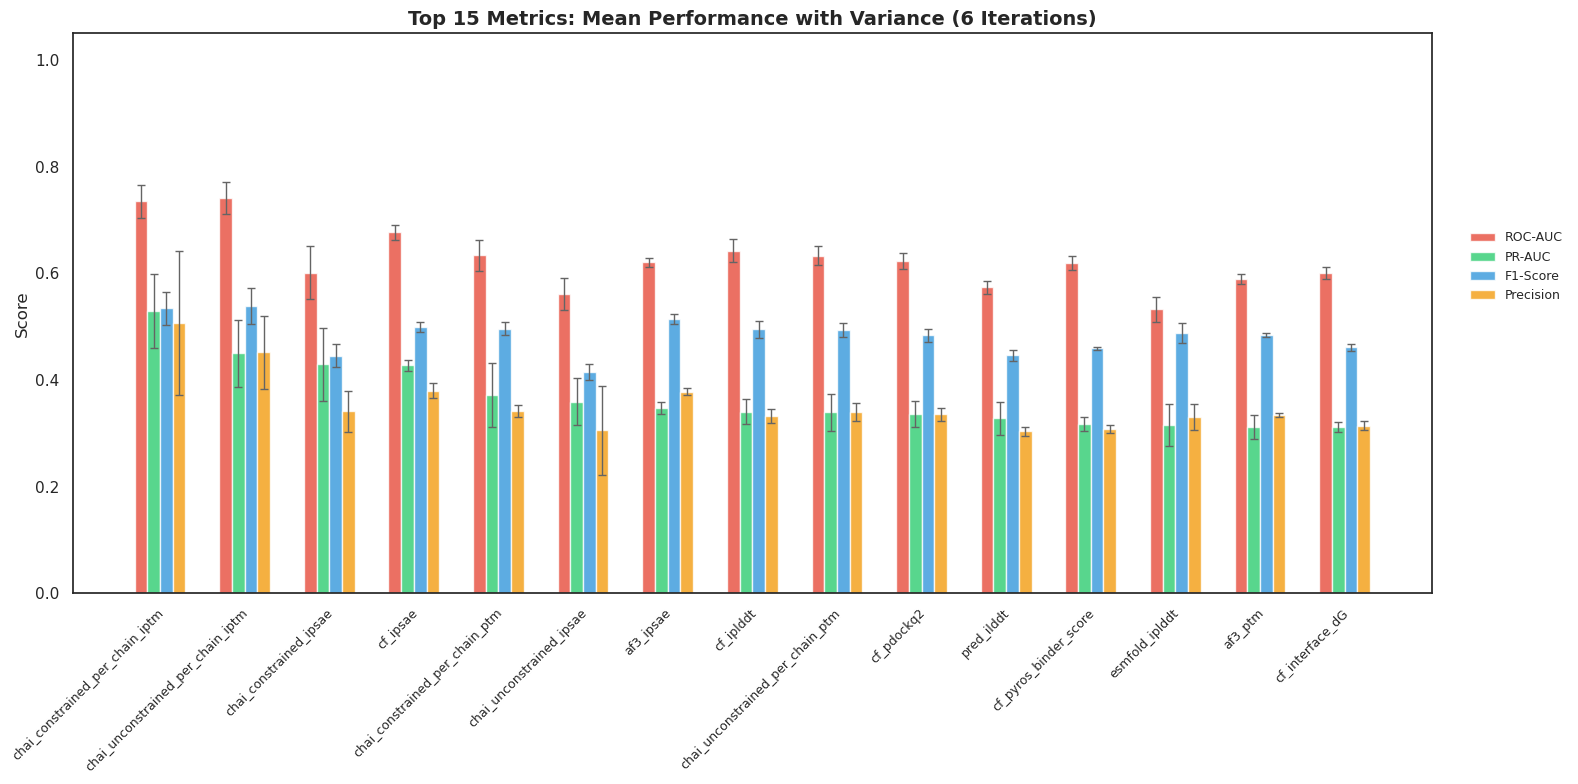

In [15]:
import matplotlib.pyplot as plt

# top 15 based on the mean PR-AUC
top_15 = stats_df.head(15).copy()

fig, ax = plt.subplots(figsize=(16, 8))
x_pos = range(len(top_15))
width = 0.15

metrics_to_plot = [
    ('aligned_roc', 'ROC-AUC', '#e74c3c'),
    ('pr_auc', 'PR-AUC', '#2ecc71'),
    ('f1', 'F1-Score', '#3498db'),
    ('precision', 'Precision', '#f39c12'),
    #('recall', 'Recall', '#9b59b6')
]

# plot each metric with its error bars
for i, (col, label, color) in enumerate(metrics_to_plot):
    # Calculate offset for grouped bar
    offset = (i - 2) * width 
    
    ax.bar(
        [p + offset for p in x_pos], 
        top_15[f'{col}_mean'], 
        width, 
        yerr=top_15[f'{col}_std'], # var
        label=label, 
        color=color, 
        alpha=0.8,
        capsize=3,
        error_kw={'elinewidth': 1, 'ecolor': "#646464"}
    )

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Top 15 Metrics: Mean Performance with Variance (6 Iterations)', 
             fontsize=14, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels(top_15['metric'], rotation=45, ha='right', fontsize=9)

# Place legend outside to the right
ax.legend(fontsize=9, loc='lower left', bbox_to_anchor=(1.02, 0.5), frameon=False)

ax.set_ylim([0, 1.05]) # room for error bars
ax.grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top15_metrics_variance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Visualizations

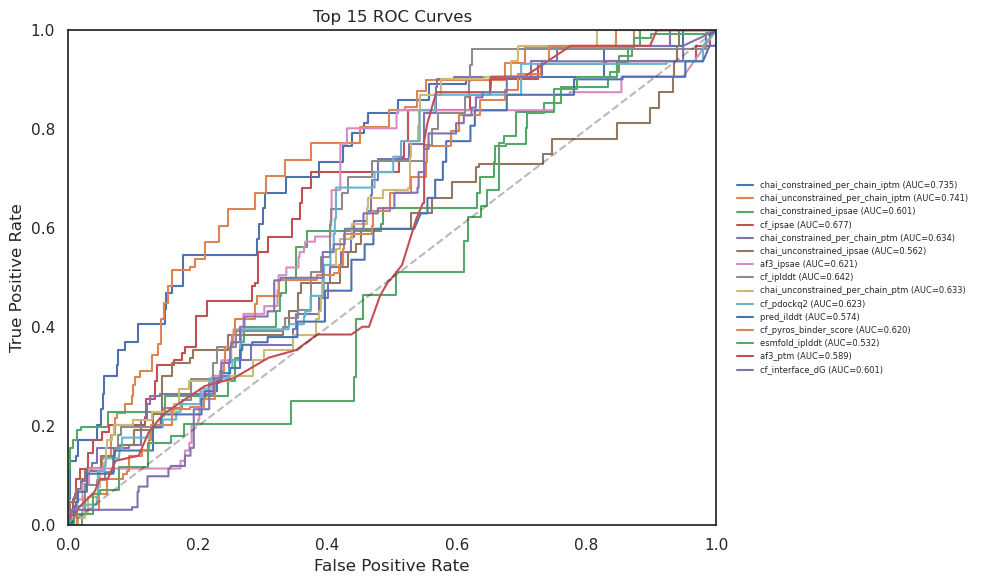

In [16]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(10, 6))

for _, row in top_15.iterrows():
    metric = row['metric']
    aligned_roc = row['aligned_roc_mean']
    direction = row['direction_mean']
    
    y_true = scores_df['binder'].values
    clean_idx = scores_df[metric].notna()
    
    y_score = scores_df.loc[clean_idx, metric].values * direction
    y_true_clean = y_true[clean_idx]
    
    fpr, tpr, _ = roc_curve(y_true_clean, y_score)
    
    ax.plot(fpr, tpr, linewidth=1.5, label=f'{metric} (AUC={aligned_roc:.3f})')

# diagonal reference
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Top 15 ROC Curves')

ax.legend(fontsize=6, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()

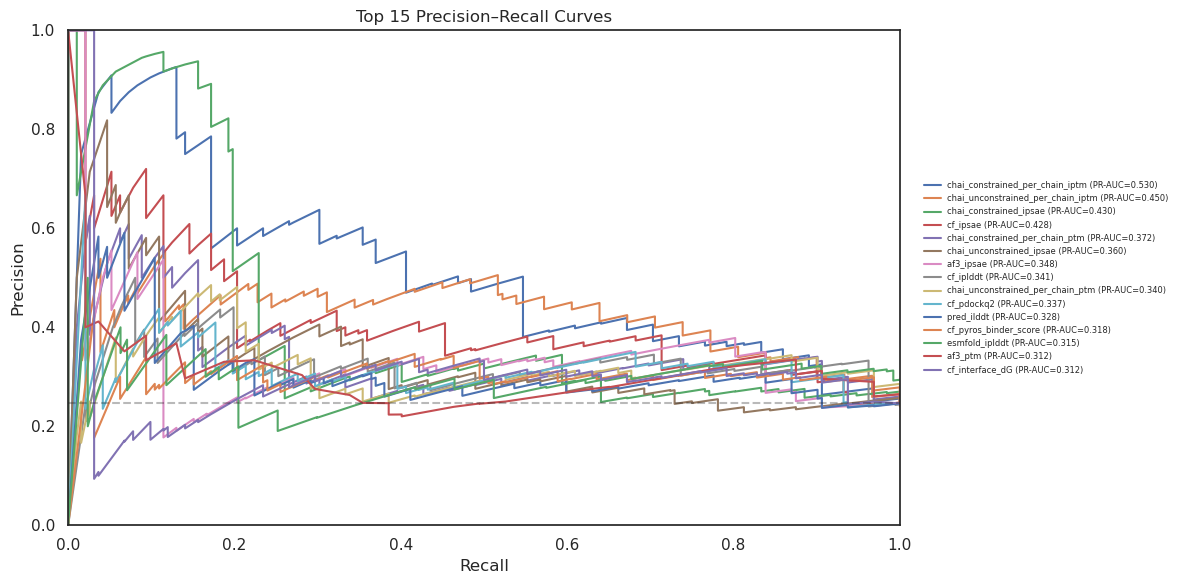

In [17]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))


for i, (_, row) in enumerate(top_15.iterrows()):
    metric = row['metric']
    pr_auc_value = row['pr_auc_mean']
    
    y_true = scores_df['binder'].values
    clean_idx = scores_df[metric].notna()
    
    y_score = scores_df.loc[clean_idx, metric].values
    y_true_clean = y_true[clean_idx]
    
    # skip invalid cases
    if len(np.unique(y_true_clean)) < 2:
        continue
    
    precision, recall, _ = precision_recall_curve(y_true_clean, y_score)

    
    ax.plot(recall, precision, label=f'{metric} (PR-AUC={pr_auc_value:.3f})')

# baseline (positive class prevalence)
baseline = y_true.mean()
ax.hlines(baseline, 0, 1, colors='k', linestyles='--', alpha=0.3)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Top 15 Precision–Recall Curves')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(False)


ax.legend(
    fontsize=6,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pr_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()


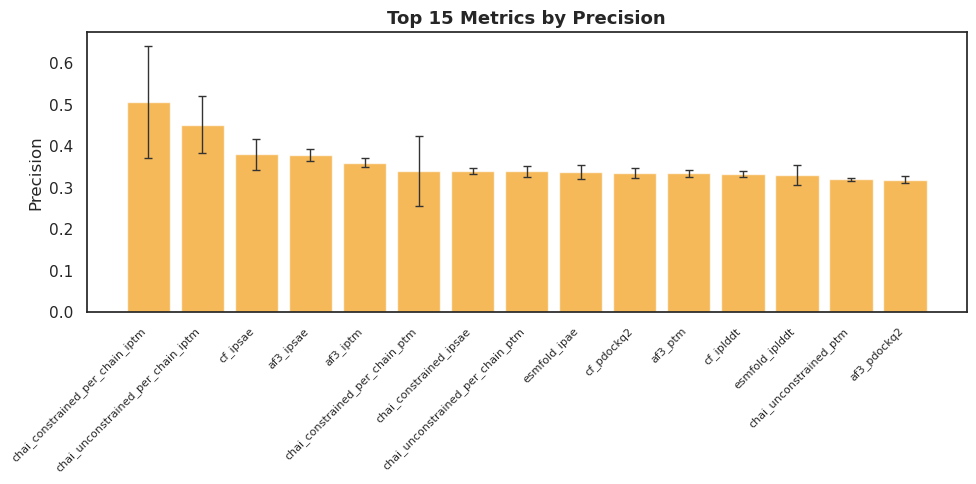

In [18]:
# rearrange rankings by precision
sorted_precision = stats_df.sort_values('precision_mean', ascending=False)   

# plot top15 precision
fig, ax = plt.subplots(figsize=(10, 5)) 
top_15_precision = sorted_precision.head(15)
ax.bar(top_15_precision['metric'], top_15_precision['precision_mean'], color='#f39c12', alpha=0.7, yerr=top_15[f'{col}_std'], capsize=3, error_kw={'elinewidth': 1, 'ecolor': '#333333'})
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Top 15 Metrics by Precision', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(top_15_precision)))
ax.set_xticklabels(top_15_precision['metric'], rotation=45, ha='right', fontsize=8)
ax.grid(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top15_precision.png', dpi=150, bbox_inches='tight')
plt.show()

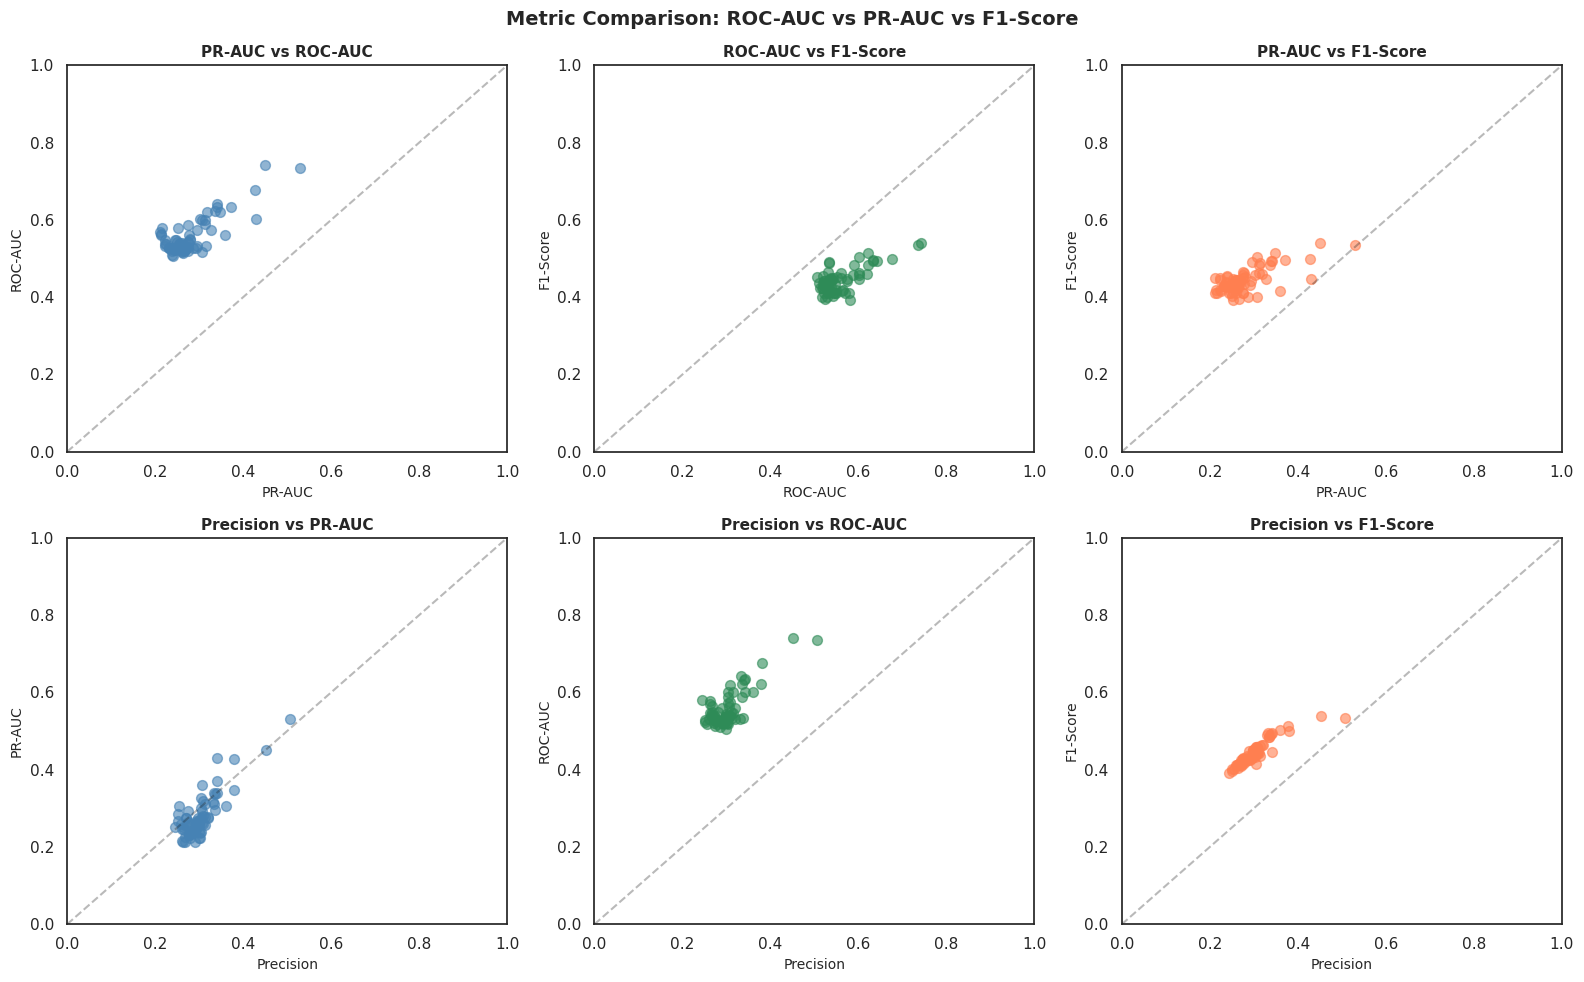

In [19]:
## Compare All Metrics: ROC-AUC, PR-AUC, and F1
sorted_precision = stats_df.sort_values('precision_mean', ascending=False)
sorted_f1 = stats_df.sort_values('f1_mean', ascending=False)
sorted_auc = stats_df.sort_values('aligned_roc_mean', ascending=False)
sorted_pr_auc = stats_df.sort_values('pr_auc_mean', ascending=False)
sorted_recall = stats_df.sort_values('recall_mean', ascending=False)

# Create comprehensive comparison dataframes
comparision = pd.DataFrame({
    'ROC-AUC': sorted_auc['aligned_roc_mean'],
    'PR-AUC': sorted_pr_auc['pr_auc_mean'],
    'F1-Score': sorted_f1['f1_mean'],
    'Precision': sorted_precision['precision_mean'],
    'Recall': sorted_recall['recall_mean']
}).fillna(0).sort_values('PR-AUC', ascending=False)

#print(comparision.to_string())


# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ROC-AUC vs PR-AUC
ax = axes[0, 0]
ax.scatter(comparision['PR-AUC'], comparision['ROC-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('ROC-AUC', fontsize=10)
ax.set_title('PR-AUC vs ROC-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# ROC-AUC vs F1
ax = axes[0, 1]
ax.scatter(comparision['ROC-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('ROC-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# PR-AUC vs F1
ax = axes[0, 2]
ax.scatter(comparision['PR-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('PR-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vs PR-AUC
ax = axes[1, 0]
ax.scatter(comparision['Precision'], comparision['PR-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('Precision vs PR-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vsROC-AUC 
ax = axes[1, 1]
ax.scatter(comparision['Precision'], comparision['ROC-AUC'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('ROC-AUC', fontsize=10)
ax.set_title('Precision vs ROC-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vs F1
ax = axes[1, 2]
ax.scatter(comparision['Precision'], comparision['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('Precision vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])



plt.suptitle('Metric Comparison: ROC-AUC vs PR-AUC vs F1-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'metrics_comparison_combined.png', dpi=150, bbox_inches='tight')
plt.show()

#### Quadrant plots

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

def plot_top_quadrant(scores_df, stats_df, label_points=False):
    # Get Top 2 by PR-AUC
    top_20 = stats_df.sort_values(by='pr_auc_mean', ascending=False).head(20)
    if len(top_20) < 2: return
    
    # Selecting by index
    m1_info, m2_info = top_20.iloc[2], top_20.iloc[3]
    
    m1, t1, d1 = m1_info['metric'], m1_info['opt_threshold_mean'], m1_info['direction_mean']
    m2, t2, d2 = m2_info['metric'], m2_info['opt_threshold_mean'], m2_info['direction_mean']

    # AGGREGATE: Instead of plotting every iteration, plot the MEAN of each sample
    plot_df = scores_df.groupby(['source', 'sample', 'type', 'binder'])[[m1, m2]].agg(['mean', 'std']).reset_index()
    
    # Flatten multi-index columns: 'metric_mean', 'metric_std'
    plot_df.columns = [f"{c[0]}_{c[1]}" if c[1] else c[0] for c in plot_df.columns]

    # Map alpha values directly into the dataframe
    alpha_dict = {"target_shuffle": 0.4, "original": 1.0, "alanine_scan": 1.0}
    plot_df["alpha"] = plot_df["type"].map(alpha_dict)

    plot_df.to_csv(OUTPUT_DIR / 'plot_df.csv', index=False) 

    plt.figure(figsize=(10, 10))

# 2. DEFINE MAPPINGS
    colors_map = {'germinal': "#2ecc71", 'mcmahon': "#d6a439", 'snir_ab': "#1f3397"}
    marker_map = {0: 'X', 1: 'o'} # Check if your binder is 0/1 or True/False
    alpha_map = {"target_shuffle": 0.4, "original": 1.0, "alanine_scan": 1.0}

    # 3. PLOT (Turn legend OFF to prevent column names from appearing)
    for t, subdf in plot_df.groupby("type"):
        sns.scatterplot(
            data=subdf,
            x=f"{m1}_mean", y=f"{m2}_mean",
            hue='source', palette=colors_map,
            style='binder', markers=marker_map,
            s=100, alpha=alpha_map.get(t, 1.0),
            edgecolor='w', legend=False # <--- CRITICAL
        )

    # 4. MANUAL AXIS LABELS (This fixes the "whole column name" issue)
    plt.xlabel(f"{m1}\n(PR-AUC: {m1_info['pr_auc_mean']:.3f})", fontsize=11)
    plt.ylabel(f"{m2}\n(PR-AUC: {m2_info['pr_auc_mean']:.3f})", fontsize=11)
    plt.title(f"Comparing Metrics: {m1} vs {m2}\n", fontsize=14, fontweight='bold')

    # 5. BUILD CUSTOM LEGEND
    legend_handles = []
    
    # Section: Source
    legend_handles.append(mpatches.Patch(color='none', label='SOURCE'))
    for label, color in colors_map.items():
        legend_handles.append(mlines.Line2D([], [], color=color, marker='s', linestyle='None', markersize=8, label=label))

    # Section: Binder
    #legend_handles.append(mpatches.Patch(color='none', label='BINDER'))
    #for val, marker in marker_map.items():
        #legend_handles.append(mlines.Line2D([], [], color='gray', marker=marker, linestyle='None', markersize=8, label=f"Binder: {val}"))

    # Section: Type
    #legend_handles.append(mpatches.Patch(color='none', label='TYPE'))
    #for label, alpha in alpha_map.items():
        #legend_handles.append(mlines.Line2D([], [], color='gray', marker='o', linestyle='None', markersize=8, alpha=alpha, label=label))

    # Thresholds (add to legend too if you like)
    t1_line = plt.axvline(t1, color='black', linestyle='--', alpha=0.3)
    t2_line = plt.axhline(t2, color='black', linestyle='--', alpha=0.3)
    #legend_handles.extend([t1_line, t2_line])

    plt.legend(handles=legend_handles, fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)
    
    # ... [Keep adjust_text logic if needed] ...

    plt.tight_layout()
    plt.show()

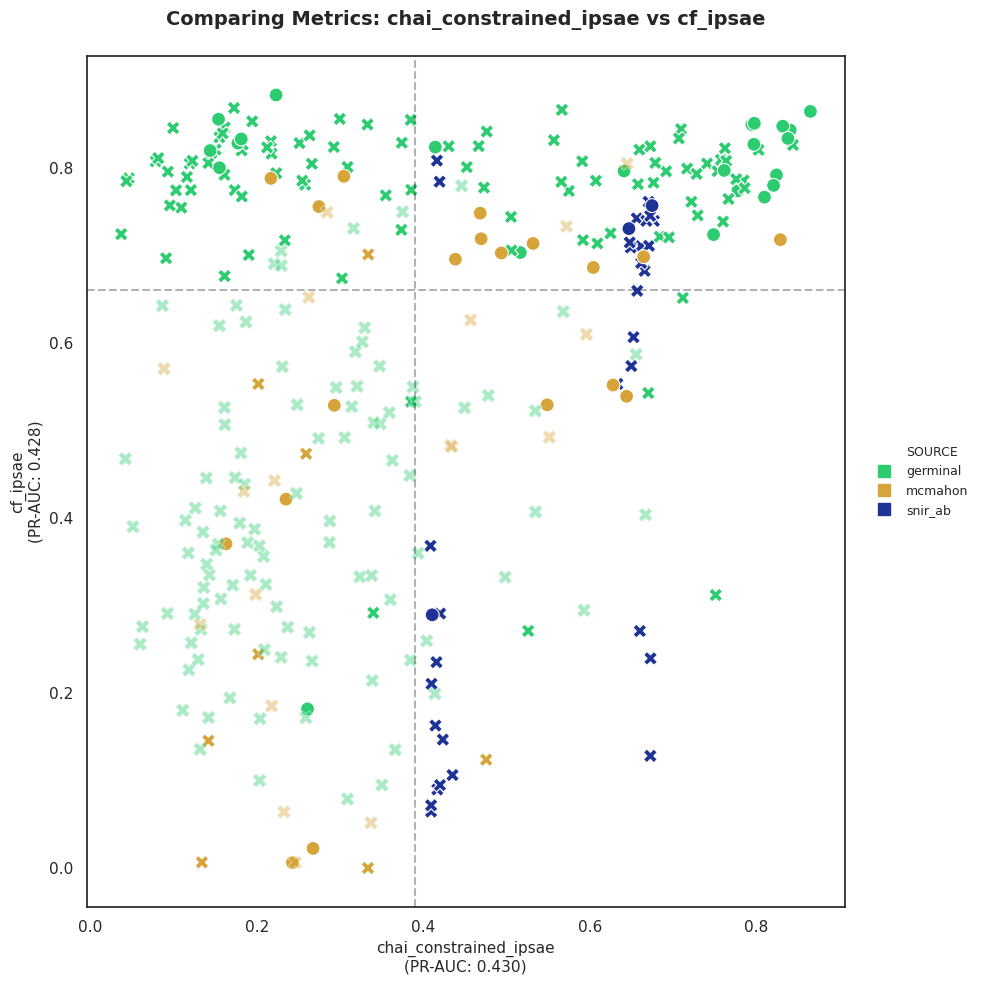

In [27]:
plot_top_quadrant(scores_df, stats_df)

In [28]:
import plotly.graph_objects as go


top_20 = stats_df.sort_values(by='pr_auc_mean', ascending=False).head(20)

m1_info, m2_info = top_20.iloc[2], top_20.iloc[3]

m1, t1, d1 = m1_info['metric'], m1_info['opt_threshold_mean'], m1_info['direction_mean']
m2, t2, d2 = m2_info['metric'], m2_info['opt_threshold_mean'], m2_info['direction_mean']

plot_df = (
    scores_df
    .groupby(['source', 'sample', 'type', 'binder'])[[m1, m2]]
    .agg(['mean', 'std'])
    .reset_index()
)

plot_df.columns = [
    f"{c[0]}_{c[1]}" if c[1] else c[0]
    for c in plot_df.columns
]


colors_map = {
    'germinal': "#2ecc71",
    'mcmahon': "#d6a439",
    'snir_ab': "#1f3397"
}

marker_map = {
    0: 'x',
    1: 'circle'
}



alpha_map = {
    "target_shuffle": 0.4,
    "original": 1.0,
    "alanine_scan": 1.0
}

# figure setup

fig = go.Figure()

# loop by type so opacity is consistent
for t, type_df in plot_df.groupby("type"):

    opacity = alpha_map.get(t, 1.0)

    # then split by source + binder
    for (source, binder), subdf in type_df.groupby(["source", "binder"]):

        fig.add_trace(
            go.Scatter(
                x=subdf[f"{m1}_mean"],
                y=subdf[f"{m2}_mean"],

                mode='markers',
                
                marker=dict(
                    color=colors_map[source],
                    symbol=marker_map[binder],
                    size=8,
                    opacity=opacity,
                    line=dict(width=0)
                ),

                name=f"{source} | {t} | binder={binder}",

                text=subdf["sample"],

                hovertemplate=(
                    "<b>%{text}</b><br>"
                    f"{m1}: %{{x:.3f}}<br>"
                    f"{m2}: %{{y:.3f}}<br>"
                    f"source: {source}<br>"
                    f"type: {t}<br>"
                    f"binder: {binder}<br>"
                    "<extra></extra>"
                ),

                showlegend=True
            )
        )


# Threshold lines
fig.add_vline(
    x=t1,
    line_dash="dash",
    line_color="black",
    opacity=0.3
)

fig.add_hline(
    y=t2,
    line_dash="dash",
    line_color="black",
    opacity=0.3
)


# Layout
fig.update_layout(
    width=900,
    height=700,
    plot_bgcolor='white',
    title=f"Comparing Metrics: {m1} vs {m2}",
    xaxis_title=f"{m1}<br>(PR-AUC: {m1_info['pr_auc_mean']:.3f})",
    yaxis_title=f"{m2}<br>(PR-AUC: {m2_info['pr_auc_mean']:.3f})",
    legend_title="Source / Type / Binder"
)

fig.show()

In [30]:
top_20 = stats_df.sort_values(by='pr_auc_mean', ascending=False).head(20)


print(top_20["metric"].tolist())

['chai_constrained_per_chain_iptm', 'chai_unconstrained_per_chain_iptm', 'chai_constrained_ipsae', 'cf_ipsae', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_ipsae', 'af3_ipsae', 'cf_iplddt', 'chai_unconstrained_per_chain_ptm', 'cf_pdockq2', 'pred_ilddt', 'cf_pyros_binder_score', 'esmfold_iplddt', 'af3_ptm', 'cf_interface_dG', 'pred_lddt', 'af3_iptm', 'af3_interface_dG_SASA_ratio', 'esmfold_ipae', 'cf_interface_dG_SASA_ratio']


In [45]:
scores_df.head()

,source,type,binder,KD[M],EC50[M],sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,...,boltz_template_ipsae,boltz_template_pdockq,boltz_template_pdockq2,boltz_template_lis,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm,iteration,binder_type
0,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-609,6.376025,88.098892,14.46,1.51,...,0.821457,0.3654,0.9208,0.4745,0.886037,0.897680,0.171786,0.758631,0,Binder
1,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_404-601,6.893648,87.943351,19.06,1.99,...,0.105424,0.3059,0.0374,0.0189,0.878948,0.880200,0.147295,0.598787,0,Binder
2,mcmahon,original,1,4.310000e-07,NaN,Nb.b201_HSA_25-609,13.189712,84.282269,154.23,10.06,...,0.819429,0.5921,0.7323,0.5462,0.877172,0.878092,0.255400,0.682429,0,Binder
3,mcmahon,original,1,2.300000e-06,NaN,Nb.AQ100_Adiponectin,12.931578,81.319338,205.51,11.33,...,0.268686,0.2883,0.0783,0.2570,0.882637,0.875993,0.159133,0.256621,0,Binder
4,mcmahon,original,0,NaN,NaN,Nb.AQ101_Adiponectin,13.803496,80.758365,46.76,3.01,...,0.212057,0.1630,0.0450,0.1986,0.881152,0.878127,0.171685,0.326672,0,Non-Binder


In [32]:
top20 = scores_df[['source','type','binder','KD[M]','EC50[M]','sample', 'iteration', 'chai_constrained_per_chain_iptm', 'chai_unconstrained_per_chain_iptm', 'chai_constrained_ipsae', 'cf_ipsae', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_ipsae', 'af3_ipsae', 'cf_iplddt', 'chai_unconstrained_per_chain_ptm', 'cf_pdockq2', 'pred_ilddt', 'cf_pyros_binder_score', 'esmfold_iplddt', 'af3_ptm', 'cf_interface_dG', 'pred_lddt', 'af3_iptm', 'af3_interface_dG_SASA_ratio', 'esmfold_ipae', 'cf_interface_dG_SASA_ratio']]
top20 = top20.to_csv("/home/bri/pymol/EDA/static/scores2combine.csv", index=False)


### archiv


#### ROC AUC

A receiver operating characteristic curve, or ROC curve, is a graphical plot that illustrates the performance of a binary classifier model (although it can be generalized to multiple classes) at varying threshold values.
The ROC curve is the plot of the true positive rate (TPR) against the false positive rate (FPR) at each threshold setting.
   - Less sensitive to class imbalance
   - Can be misleadingly high even with poor minority class performance
   - Still useful for overall ranking but don't rely solely on it

In [69]:
# Calculate ROC-AUC 
# TO DO: implement directionality
auc_scores = {}
for col in numeric_cols:
    # Skip if column has NaN values or doesn't have enough variation
    if [col].notna().sum() < 2 or df[col].nunique() < 2:
        continue
    try:
        auc = roc_auc_score(df["binder"], df[col])
        auc_scores[col] = auc
    except:
        pass

# Sort by AUC score (descending)
sorted_auc = dict(sorted(auc_scores.items(), key=lambda x: x[1], reverse=True))


# Display as DataFrames for better visualization
print("="*60)
print("ROC AUC Scores (sorted by performance)")
print("="*60)

auc_df = pd.DataFrame(list(sorted_auc.items()), columns=['Metric', 'ROC AUC'])
auc_df = auc_df.set_index('Metric')
print(auc_df.to_string())
print(f"\nBest metric: {list(sorted_auc.keys())[0]} (AUC: {list(sorted_auc.values())[0]:.4f})")

AttributeError: 'list' object has no attribute 'notna'

In [ ]:
auc_df

,ROC AUC
Metric,
af3_iplddt,0.905797
cf_iplddt,0.888889
af3_ranking_score,0.850242
af3_ipsae,0.847826
af3_iptm,0.835749
boltz_free_per_chain_pair_iptm,0.797101
cf_plddt,0.792271
boltz_free_iptm,0.787440
chai_unconstrained_score,0.780193


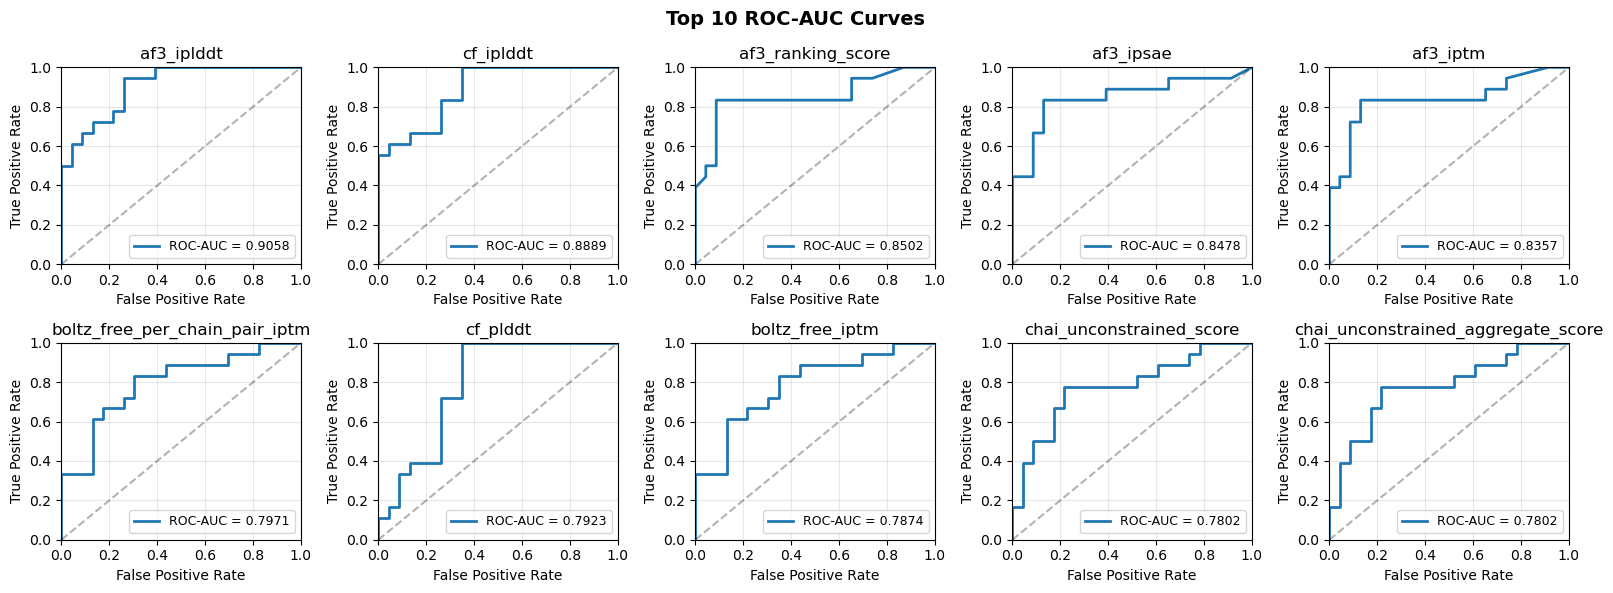

In [ ]:
# plot roc-auc
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

top_10 = auc_df.head(10)

for col_idx, metric in enumerate(top_10.index):  # Iterate over index (metric names)
    ax = axes[col_idx]
    
    fpr, tpr, _ = roc_curve(df["binder"], df[metric])
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, linewidth=2, label=f'ROC-AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{metric}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Top 10 ROC-AUC Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### precision recall
   - Focuses on minority class (binders)
   - More informative than ROC-AUC for imbalanced data
   - Recall = TP / (TP + FN): what fraction of binders we find
   - Precision = TP / (TP + FP): what fraction of predictions are correct

In [ ]:
from sklearn.metrics import precision_recall_curve, auc as auc_pr

# Calculate Precision-Recall AUC for A,C and B,C
print("="*60)
print("Precision-Recall AUC Scores")
print("="*60)

pr_auc = {}
for col in numeric_cols:
    if df[col].notna().sum() < 2 or df[col].nunique() < 2:
        continue
    try:
        precision, recall, _ = precision_recall_curve(df["binder"], df[col])
        pr_auc_score = auc_pr(recall, precision)
        pr_auc[col] = pr_auc_score
    except:
        pass

sorted_pr_auc = dict(sorted(pr_auc.items(), key=lambda x: x[1], reverse=True))


# Display as DataFrames for better visualization
print("="*60)
print("ROC AUC Scores (sorted by performance)")
print("="*60)

pr_auc_df = pd.DataFrame(list(sorted_pr_auc.items()), columns=['Metric', 'PR-AUC'])
pr_auc_df = pr_auc_df.set_index('Metric')
print(pr_auc_df.to_string())
print(f"\nBest metric: {list(sorted_pr_auc.keys())[0]} (PR-AUC: {list(sorted_pr_auc.values())[0]:.4f})")

Precision-Recall AUC Scores
ROC AUC Scores (sorted by performance)
                                      PR-AUC
Metric                                      
af3_iplddt                          0.890310
cf_iplddt                           0.877692
af3_ranking_score                   0.860230
af3_ipsae                           0.854286
af3_iptm                            0.844271
boltz_free_per_chain_pair_iptm      0.778722
boltz_free_iptm                     0.770932
chai_unconstrained_score            0.753643
chai_unconstrained_aggregate_score  0.753643
chai_unconstrained_iptm             0.744991
boltz_template_per_chain_pair_iptm  0.733130
chai_constrained_score              0.732773
chai_constrained_aggregate_score    0.732773
boltz_template_iptm                 0.729231
chai_constrained_iptm               0.722849
chai_unconstrained_ptm              0.711568
boltz_free_ptm                      0.709901
cf_plddt                            0.691722
pred_ilddt                       

In [ ]:
pr_auc_df.head()

,metric,PR-AUC
0,af3_iplddt,0.890310
1,cf_iplddt,0.877692
2,af3_ranking_score,0.860230
3,af3_ipsae,0.854286
4,af3_iptm,0.844271


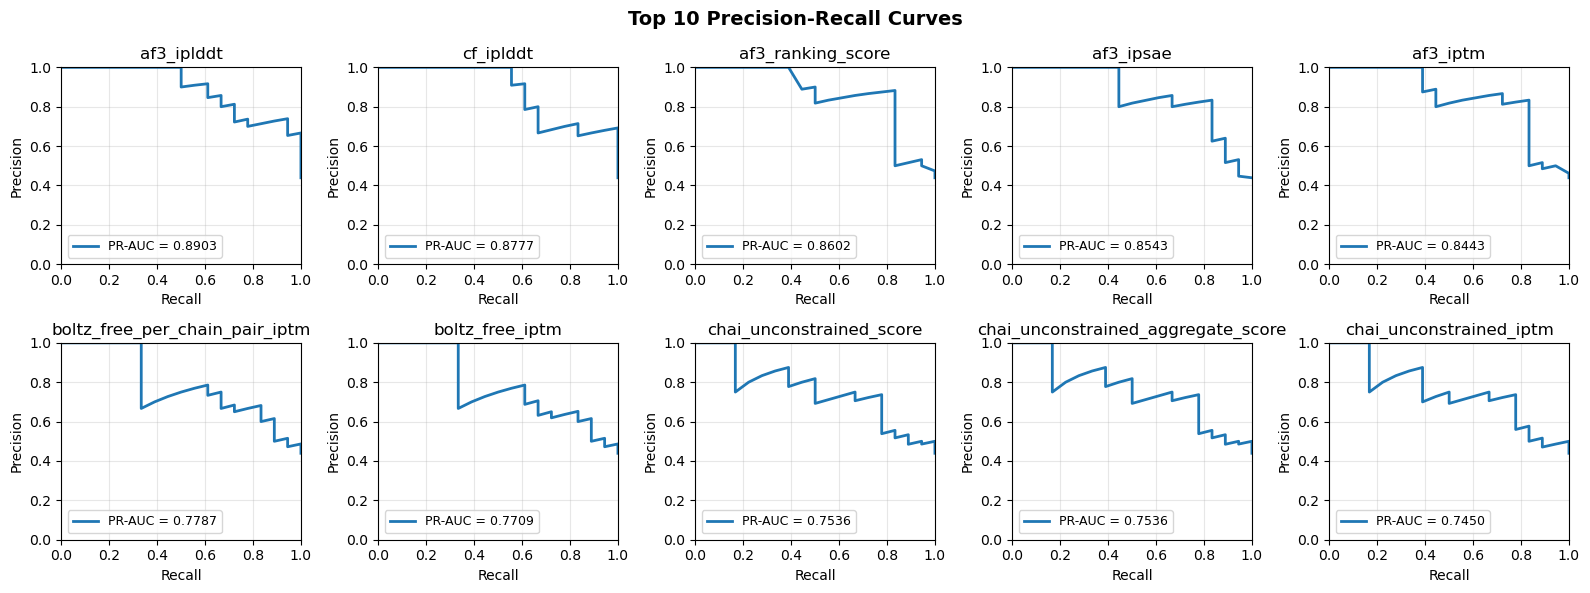

In [ ]:
## Plot Precision-Recall Curves

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

top_10 = pr_auc_df.head(10)

for col_idx, metric in enumerate(top_10.index): 
    ax = axes[col_idx]
    
    pr_auc_value = pr_auc_df.loc[metric, 'PR-AUC']
    precision, recall, _ = precision_recall_curve(df["binder"], df[metric])
    
    ax.plot(recall, precision, linewidth=2, label=f'PR-AUC = {pr_auc_value:.4f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{metric}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Top 10 Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


#### F1 score
   - Harmonic mean of precision and recall
   - Single number summarizing trade-off between both metrics
   - Best for decision-making at specific threshold

In [ ]:
## F1 Score Analysis

from sklearn.metrics import f1_score
import numpy as np

print("\n" + "="*60)
print("F1 Score Analysis")
print("="*60)

# Calculate F1 scores for A,C interface
f1_scores = {}
for col in numeric_cols:
    if df[col].notna().sum() < 2 or df[col].nunique() < 2:
        continue
    try:
        # Find optimal threshold using Youden's J statistic
        from sklearn.metrics import roc_curve
        fpr, tpr, thresholds = roc_curve(df["binder"], df[col])
        j_scores = tpr - fpr
        best_threshold = thresholds[np.argmax(j_scores)]
        
        y_pred = (df[col] >= best_threshold).astype(int)
        f1 = f1_score(df["binder"], y_pred)
        f1_scores[col] = f1
    except:
        pass

sorted_f1 = dict(sorted(f1_scores.items(), key=lambda x: x[1], reverse=True))

print(f"\nTop 10 metrics (F1 Score):")
for i, (metric, f1) in enumerate(list(sorted_f1.items())[:10], 1):
    print(f"  {i:2d}. {metric:40s} F1 = {f1:.4f}")


F1 Score Analysis

Top 10 metrics (F1 Score):
   1. af3_ranking_score                        F1 = 0.8571
   2. af3_ipsae                                F1 = 0.8333
   3. af3_iptm                                 F1 = 0.8333
   4. af3_iplddt                               F1 = 0.8293
   5. cf_plddt                                 F1 = 0.8182
   6. cf_iplddt                                F1 = 0.8182
   7. chai_unconstrained_score                 F1 = 0.7568
   8. chai_unconstrained_aggregate_score       F1 = 0.7568
   9. chai_unconstrained_iptm                  F1 = 0.7568
  10. chai_unconstrained_interface_iptm        F1 = 0.7568



Top 10 Metrics - A,C Interface (ROC-AUC, PR-AUC, F1-Score)
                                     ROC-AUC    PR-AUC  F1-Score
af3_iplddt                          0.905797  0.890310  0.829268
cf_iplddt                           0.888889  0.877692  0.818182
af3_ranking_score                   0.850242  0.860230  0.857143
af3_ipsae                           0.847826  0.854286  0.833333
af3_iptm                            0.835749  0.844271  0.833333
boltz_free_per_chain_pair_iptm      0.797101  0.778722  0.750000
cf_plddt                            0.792271  0.691722  0.818182
boltz_free_iptm                     0.787440  0.770932  0.731707
chai_unconstrained_score            0.780193  0.753643  0.756757
chai_unconstrained_aggregate_score  0.780193  0.753643  0.756757


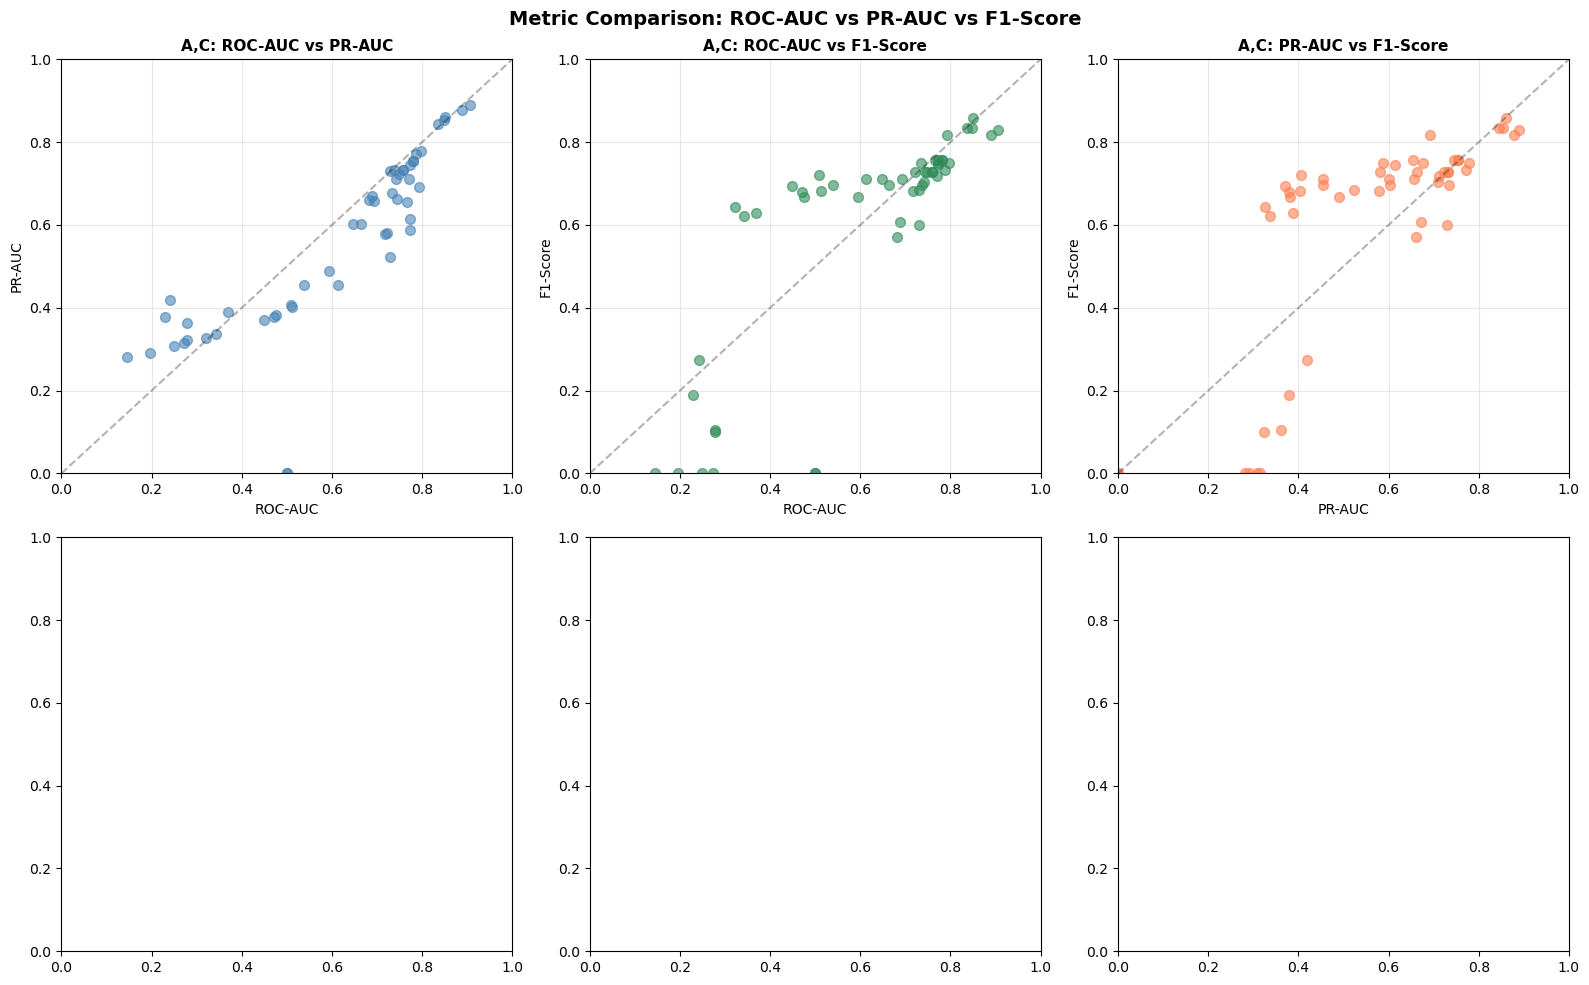

In [ ]:
## Compare All Metrics: ROC-AUC, PR-AUC, and F1

# Create comprehensive comparison dataframes
comparision = pd.DataFrame({
    'ROC-AUC': sorted_auc,
    'PR-AUC': sorted_pr_auc,
    'F1-Score': sorted_f1
}).fillna(0).sort_values('ROC-AUC', ascending=False)


print("\n" + "="*80)
print("Top 10 Metrics - A,C Interface (ROC-AUC, PR-AUC, F1-Score)")
print("="*80)
print(comparision.head(10).to_string())



# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# A,C: ROC-AUC vs PR-AUC
ax = axes[0, 0]
ax.scatter(comparision['ROC-AUC'], comparision['PR-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('A,C: ROC-AUC vs PR-AUC', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# A,C: ROC-AUC vs F1
ax = axes[0, 1]
ax.scatter(comparision['ROC-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('A,C: ROC-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# A,C: PR-AUC vs F1
ax = axes[0, 2]
ax.scatter(comparision['PR-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('A,C: PR-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.suptitle('Metric Comparison: ROC-AUC vs PR-AUC vs F1-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison_combined.png', dpi=150, bbox_inches='tight')
plt.show()


Ranking Comparison - A,C Interface (Top 15 by each metric)

Top 15 by ROC-AUC:
['af3_iplddt', 'cf_iplddt', 'af3_ranking_score', 'af3_ipsae', 'af3_iptm', 'boltz_free_per_chain_pair_iptm', 'cf_plddt', 'boltz_free_iptm', 'chai_unconstrained_score', 'chai_unconstrained_aggregate_score', 'cf_ipsae', 'cf_iptm', 'chai_unconstrained_iptm', 'chai_unconstrained_ptm', 'chai_unconstrained_interface_iptm']

Top 15 by PR-AUC:
['af3_iplddt', 'cf_iplddt', 'af3_ranking_score', 'af3_ipsae', 'af3_iptm', 'boltz_free_per_chain_pair_iptm', 'boltz_free_iptm', 'chai_unconstrained_score', 'chai_unconstrained_aggregate_score', 'chai_unconstrained_iptm', 'boltz_template_per_chain_pair_iptm', 'chai_constrained_score', 'chai_constrained_aggregate_score', 'boltz_template_iptm', 'chai_constrained_iptm']

Top 15 by F1-Score:
['af3_ranking_score', 'af3_ipsae', 'af3_iptm', 'af3_iplddt', 'cf_plddt', 'cf_iplddt', 'chai_unconstrained_score', 'chai_unconstrained_aggregate_score', 'chai_unconstrained_iptm', 'chai_unconstra

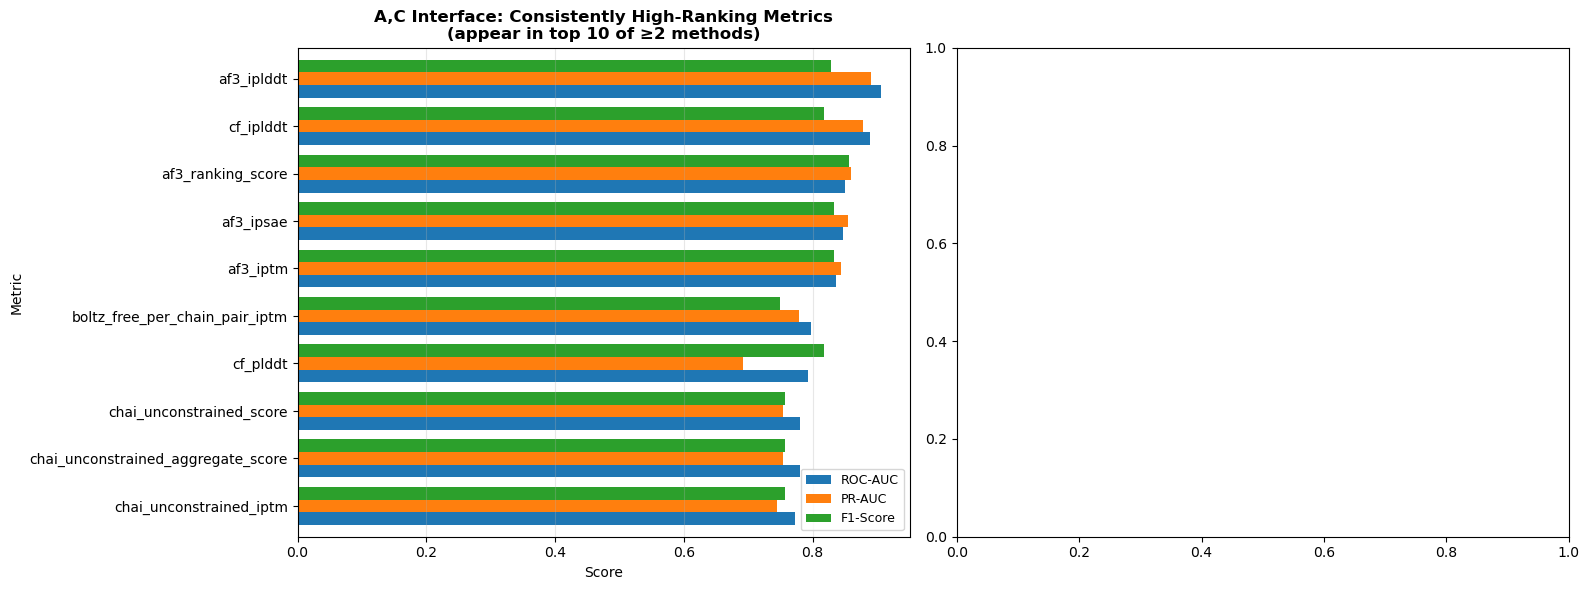

In [ ]:
## Ranking Comparison across Metrics

# Get top 15 metrics by each criterion for A,C
top_15_roc = list(sorted_auc.keys())[:15]
top_15_pr = list(sorted_pr_auc.keys())[:15]
top_15_f1 = list(sorted_f1.keys())[:15]

# Create ranking comparison table for A,C
print("\n" + "="*80)
print("Ranking Comparison - A,C Interface (Top 15 by each metric)")
print("="*80)
print(f"\nTop 15 by ROC-AUC:\n{top_15_roc}")
print(f"\nTop 15 by PR-AUC:\n{top_15_pr}")
print(f"\nTop 15 by F1-Score:\n{top_15_f1}")




# Heatmap style visualization of top metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# A,C: Identify metrics that rank consistently high
# Count how many times each metric appears in top 10 across all three methods
metric_consistency = {}
for metric in set(top_15_roc[:10] + top_15_pr[:10] + top_15_f1[:10]):
    count = 0
    if metric in top_15_roc[:10]:
        count += 1
    if metric in top_15_pr[:10]:
        count += 1
    if metric in top_15_f1[:10]:
        count += 1
    metric_consistency[metric] = count

# Get metrics that appear in top 10 of at least 2 methods
consistent_metrics = sorted([m for m, c in metric_consistency.items() if c >= 2], 
                                key=lambda x: metric_consistency[x], reverse=True)[:10]

data = comparision.loc[consistent_metrics, :].sort_values('ROC-AUC', ascending=True)
data['Consistency'] = data.index.map(lambda x: f"{metric_consistency.get(x, 0)}/3 methods")

data.plot(kind='barh', ax=ax1, width=0.8)
ax1.set_title('A,C Interface: Consistently High-Ranking Metrics\n(appear in top 10 of ≥2 methods)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Score', fontsize=10)
ax1.set_ylabel('Metric', fontsize=10)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3, axis='x')


# Print consistency summary
print("\nConsistency Analysis (Metrics appearing in top 10 of multiple evaluation methods):")
print("\nA,C Interface - Metric Consistency:")
for metric in consistent_metrics:
    consistency = metric_consistency[metric]
    print(f"  {metric:40s} appears in {consistency}/3 methods")
    

plt.tight_layout()
plt.savefig('metrics_ranking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


TOP METRICS
(Sorted by PR-AUC, then F1-Score)

--------------------------------------------------------------------------------
A,C Interface - Top 15 Metrics
--------------------------------------------------------------------------------
                                     ROC-AUC    PR-AUC  F1-Score
af3_iplddt                          0.905797  0.890310  0.829268
cf_iplddt                           0.888889  0.877692  0.818182
af3_ranking_score                   0.850242  0.860230  0.857143
af3_ipsae                           0.847826  0.854286  0.833333
af3_iptm                            0.835749  0.844271  0.833333
boltz_free_per_chain_pair_iptm      0.797101  0.778722  0.750000
boltz_free_iptm                     0.787440  0.770932  0.731707
chai_unconstrained_score            0.780193  0.753643  0.756757
chai_unconstrained_aggregate_score  0.780193  0.753643  0.756757
chai_unconstrained_iptm             0.772947  0.744991  0.756757
boltz_template_per_chain_pair_iptm  0.736715

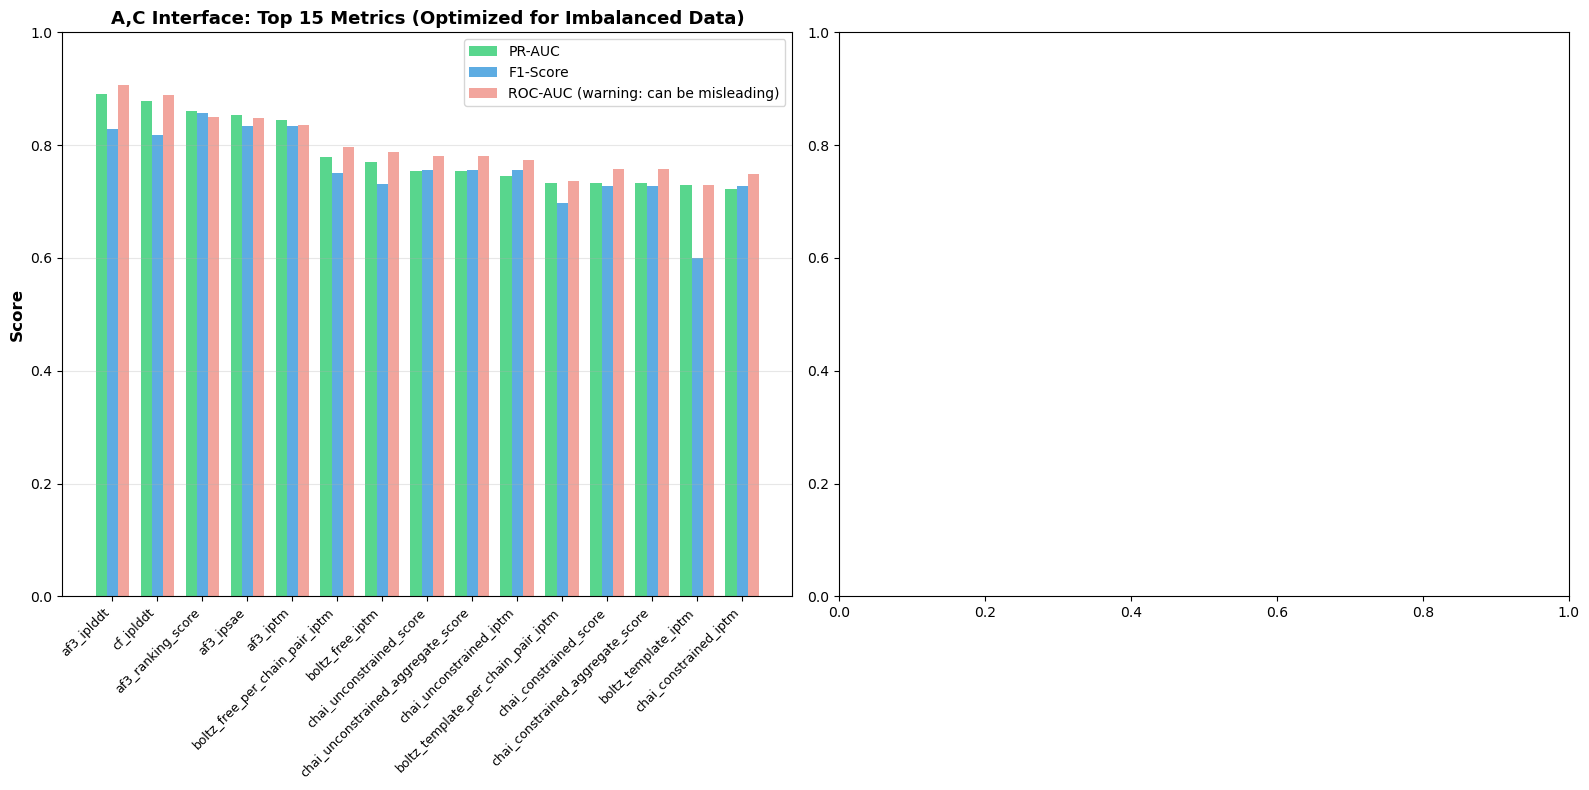


✓ Saved: metrics_optimized_for_imbalanced_data.png

KEY RECOMMENDATIONS:
  • Focus on metrics with HIGH PR-AUC (green bars)
  • Use F1-Score for deciding optimal thresholds (blue bars)
  • ROC-AUC scores (red bars) should be deprioritized for this imbalanced data


In [ ]:
## Optimized Ranking for Imbalanced Data (PR-AUC & F1 Priority)

print("\n" + "="*80)
print("TOP METRICS")
print("(Sorted by PR-AUC, then F1-Score)")
print("="*80)

# Create optimized rankings for A,C (sorted by PR-AUC first, then F1)
optimized = comparision.copy().sort_values(['PR-AUC', 'F1-Score'], ascending=False)

print("\n" + "-"*80)
print("A,C Interface - Top 15 Metrics")
print("-"*80)
print(optimized.head(15).to_string())

# Create visualization emphasizing PR-AUC and F1-Score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# A,C: Top 15 metrics by PR-AUC (not ROC-AUC)
top_15_pr_auc = optimized.head(15)
x_pos_ac = range(len(top_15_pr_auc))

width = 0.25
ax1.bar([i - width for i in x_pos_ac], top_15_pr_auc['PR-AUC'], width, label='PR-AUC', color='#2ecc71', alpha=0.8)
ax1.bar(x_pos_ac, top_15_pr_auc['F1-Score'], width, label='F1-Score', color='#3498db', alpha=0.8)
ax1.bar([i + width for i in x_pos_ac], top_15_pr_auc['ROC-AUC'], width, label='ROC-AUC (warning: can be misleading)', color='#e74c3c', alpha=0.5)

ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('A,C Interface: Top 15 Metrics (Optimized for Imbalanced Data)', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos_ac)
ax1.set_xticklabels(top_15_pr_auc.index, rotation=45, ha='right', fontsize=9)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 1])


plt.tight_layout()
plt.savefig('metrics_optimized_for_imbalanced_data.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: metrics_optimized_for_imbalanced_data.png")
print("\nKEY RECOMMENDATIONS:")
print("  • Focus on metrics with HIGH PR-AUC (green bars)")
print("  • Use F1-Score for deciding optimal thresholds (blue bars)")
print("  • ROC-AUC scores (red bars) should be deprioritized for this imbalanced data")

In [ ]:
# subsample germinal
import pandas as pd

# Define your 3 specific types
types = {
    (1, "original"): 10,       # Positive
    (0, "original"): 20,       # Hard Negative
    (0, "target_shuffle"): 20  # Easy Negative
}

all_iterations = []

for i in range(10): # 10 iterations
    parts = []
    
    # Nested unpacking: (binder, type) comes from the key, n from the value
    for (binder, type), n in types.items():
        
        # Apply BOTH filters to get the specific pool
        # This works for all 3 types because the dictionary keys match the DF values
        subset = germinal[(germinal['binder'] == binder) & 
                          (germinal['type'] == type)]
        
        # Draw n samples from this specific pool
        parts.append(subset.sample(n=n, random_state=i))
    
    # Combine the 3 parts (10+20+20 = 50 rows total per iteration)
    iteration_df = pd.concat(parts).sample(frac=1, random_state=i)
    iteration_df["iteration"] = i
    
    all_iterations.append(iteration_df)

# Final result
sub_germinal = pd.concat(all_iterations).reset_index(drop=True)

print(f"Subsampled Germinal:\n{sub_germinal['binder'].value_counts()}")
print(f"Subsampled Germinal Types:\n{sub_germinal['type'].value_counts()}")
sub_germinal.head()
sub_germinal.to_csv("/home/bri/pymol/EDA/static/germinal_outputs/subsampled_germinal.csv", index=False)